# US Births Fourier & Wavelet-Based SARIMA Analysis (1974-1987)
## Frequency Domain Approach to Time Series Modeling

This notebook demonstrates:
1. **Data loading and subsetting** - Extract 1974-1987 data from UTSD
2. **Fourier analysis** - Identify dominant seasonal frequencies using FFT
3. **Wavelet analysis** - Time-frequency decomposition and scalogram
4. **SARIMA modeling** - Fit models based on top 4 Fourier frequencies
5. **Model selection** - Compare and select best model
6. **Forecasting** - Predict 1987 (last year) using 1974-1986 training data
7. **Diagnostics** - Residual analysis and distribution

## 1. Setup and Imports

In [20]:
# Standard imports
from datasets import load_dataset
import duckdb as ddb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import analysis modules
import utilities.arima_analysis as arima
import utilities.sarima_analysis as sarima
import utilities.time_subset as tsub
import utilities.spectral_analysis as spectral

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 7)

print("✓ All imports successful")

✓ All imports successful


## 2. Load and Prepare Data

In [21]:
# Load UTSD dataset
print("Loading UTSD dataset...")
ds = load_dataset("thuml/UTSD", "UTSD-1G")
df = pd.DataFrame(ds['train'])

# Connect to DuckDB
con = ddb.connect()

print(f"Dataset loaded: {len(df)} time series")

# Filter for US births data
us_births_df = con.execute("""
    SELECT * FROM df WHERE item_id LIKE '%birth%';
""").fetch_df()

print(f"\nFound {len(us_births_df)} US births time series")

Loading UTSD dataset...


Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Dataset loaded: 68679 time series


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Found 1 US births time series


In [22]:
# Extract and prepare time series data
print("Expanding time series data...")

birth_row = us_births_df.iloc[0]
start_date = pd.to_datetime(birth_row['start'])
end_date = pd.to_datetime(birth_row['end'])
target_values = birth_row['target']

# Create date range
date_range = pd.date_range(start=start_date, periods=len(target_values), freq='D')

# Create DataFrame
births_df = pd.DataFrame({
    'datetime': date_range,
    'births': target_values
})

print(f"✓ Full dataset prepared: {len(births_df)} observations")
print(f"Date range: {births_df['datetime'].min().date()} to {births_df['datetime'].max().date()}")

Expanding time series data...
✓ Full dataset prepared: 7305 observations
Date range: 1969-01-01 to 1988-12-31


## 3. Extract Subset: 1974-1987

In [23]:
# Extract data from Jan 1974 to Dec 1987
analysis_data = tsub.extract_subset(
    births_df,
    datetime_col='datetime',
    start_date='1974-01-01',
    end_date='1987-12-31'
)

print(f"\nAnalysis period: {len(analysis_data)} days")
print(f"From {analysis_data['datetime'].min().date()} to {analysis_data['datetime'].max().date()}")
print(f"Mean births per day: {analysis_data['births'].mean():.2f}")


TIME SUBSET VALIDATION
Requested start: 1974-01-01 00:00:00
Actual start:    1974-01-01 00:00:00
Requested end:   1987-12-31 00:00:00
Actual end:      1987-12-31 00:00:00
Total records:   5113
Date range:      5112 days
✓ No gaps detected in time series


Analysis period: 5113 days
From 1974-01-01 to 1987-12-31
Mean births per day: 9635.03


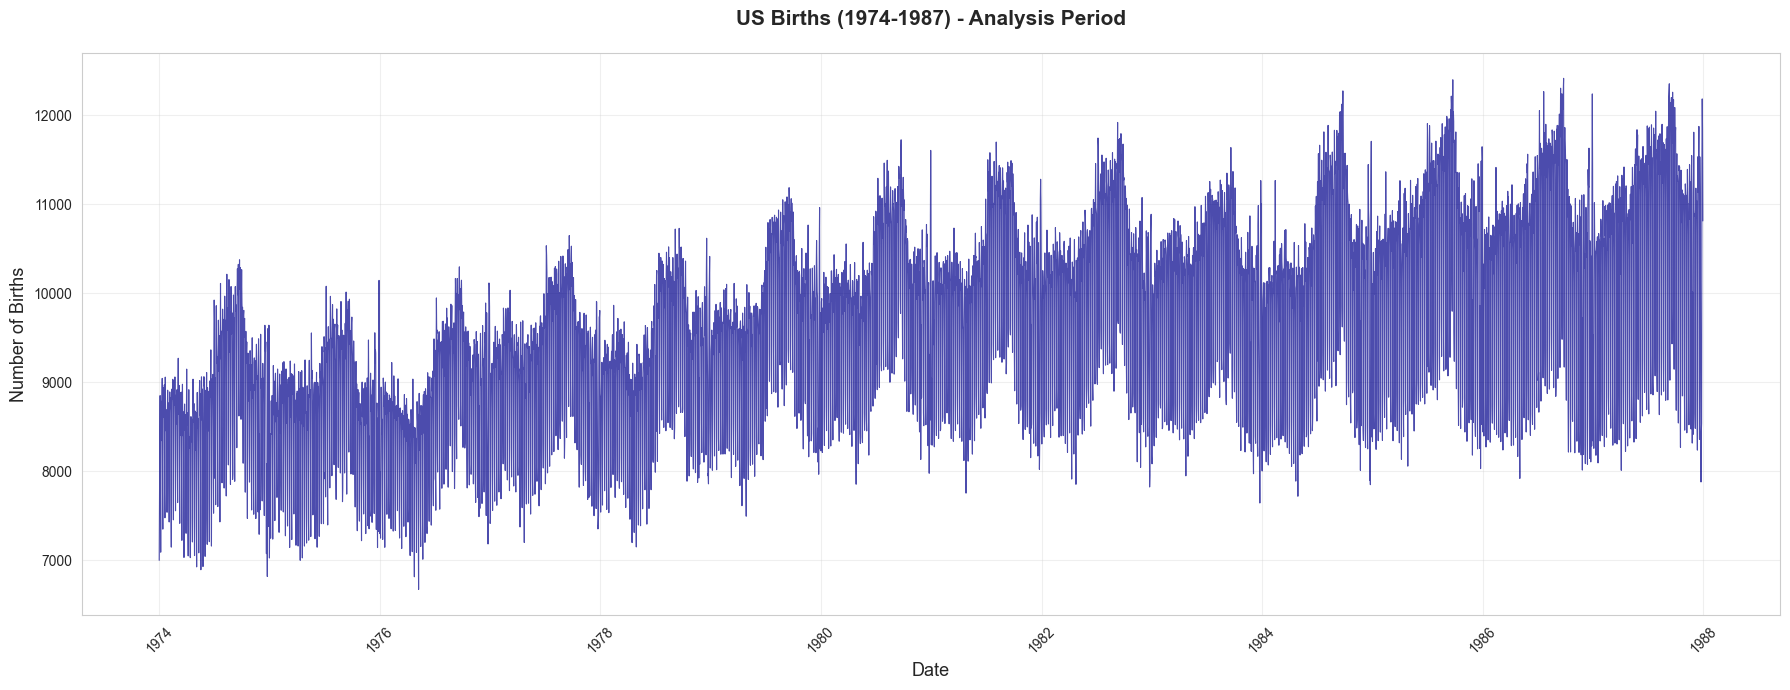

In [24]:
# Visualize the analysis period
fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(analysis_data['datetime'], analysis_data['births'],
        linewidth=0.8, color='darkblue', alpha=0.7)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Number of Births', fontsize=13)
ax.set_title('US Births (1974-1987) - Analysis Period', fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

STATIONARITY AND AUTOCORRELATION ANALYSIS

STATISTICAL TEST SUMMARY

Original Data:
  ADF Test: p-value = 0.033137 → Stationary
  KPSS Test: p-value = 0.010000 → Non-stationary
  Ljung-Box: 20 significant lags → Autocorrelated

1st Order Differenced:
  ADF Test: p-value = 0.000000 → Stationary
  KPSS Test: p-value = 0.100000 → Stationary
  Ljung-Box: 19 significant lags → Autocorrelated

2nd Order Differenced:
  ADF Test: p-value = 0.000000 → Stationary
  KPSS Test: p-value = 0.100000 → Stationary
  Ljung-Box: 20 significant lags → Autocorrelated


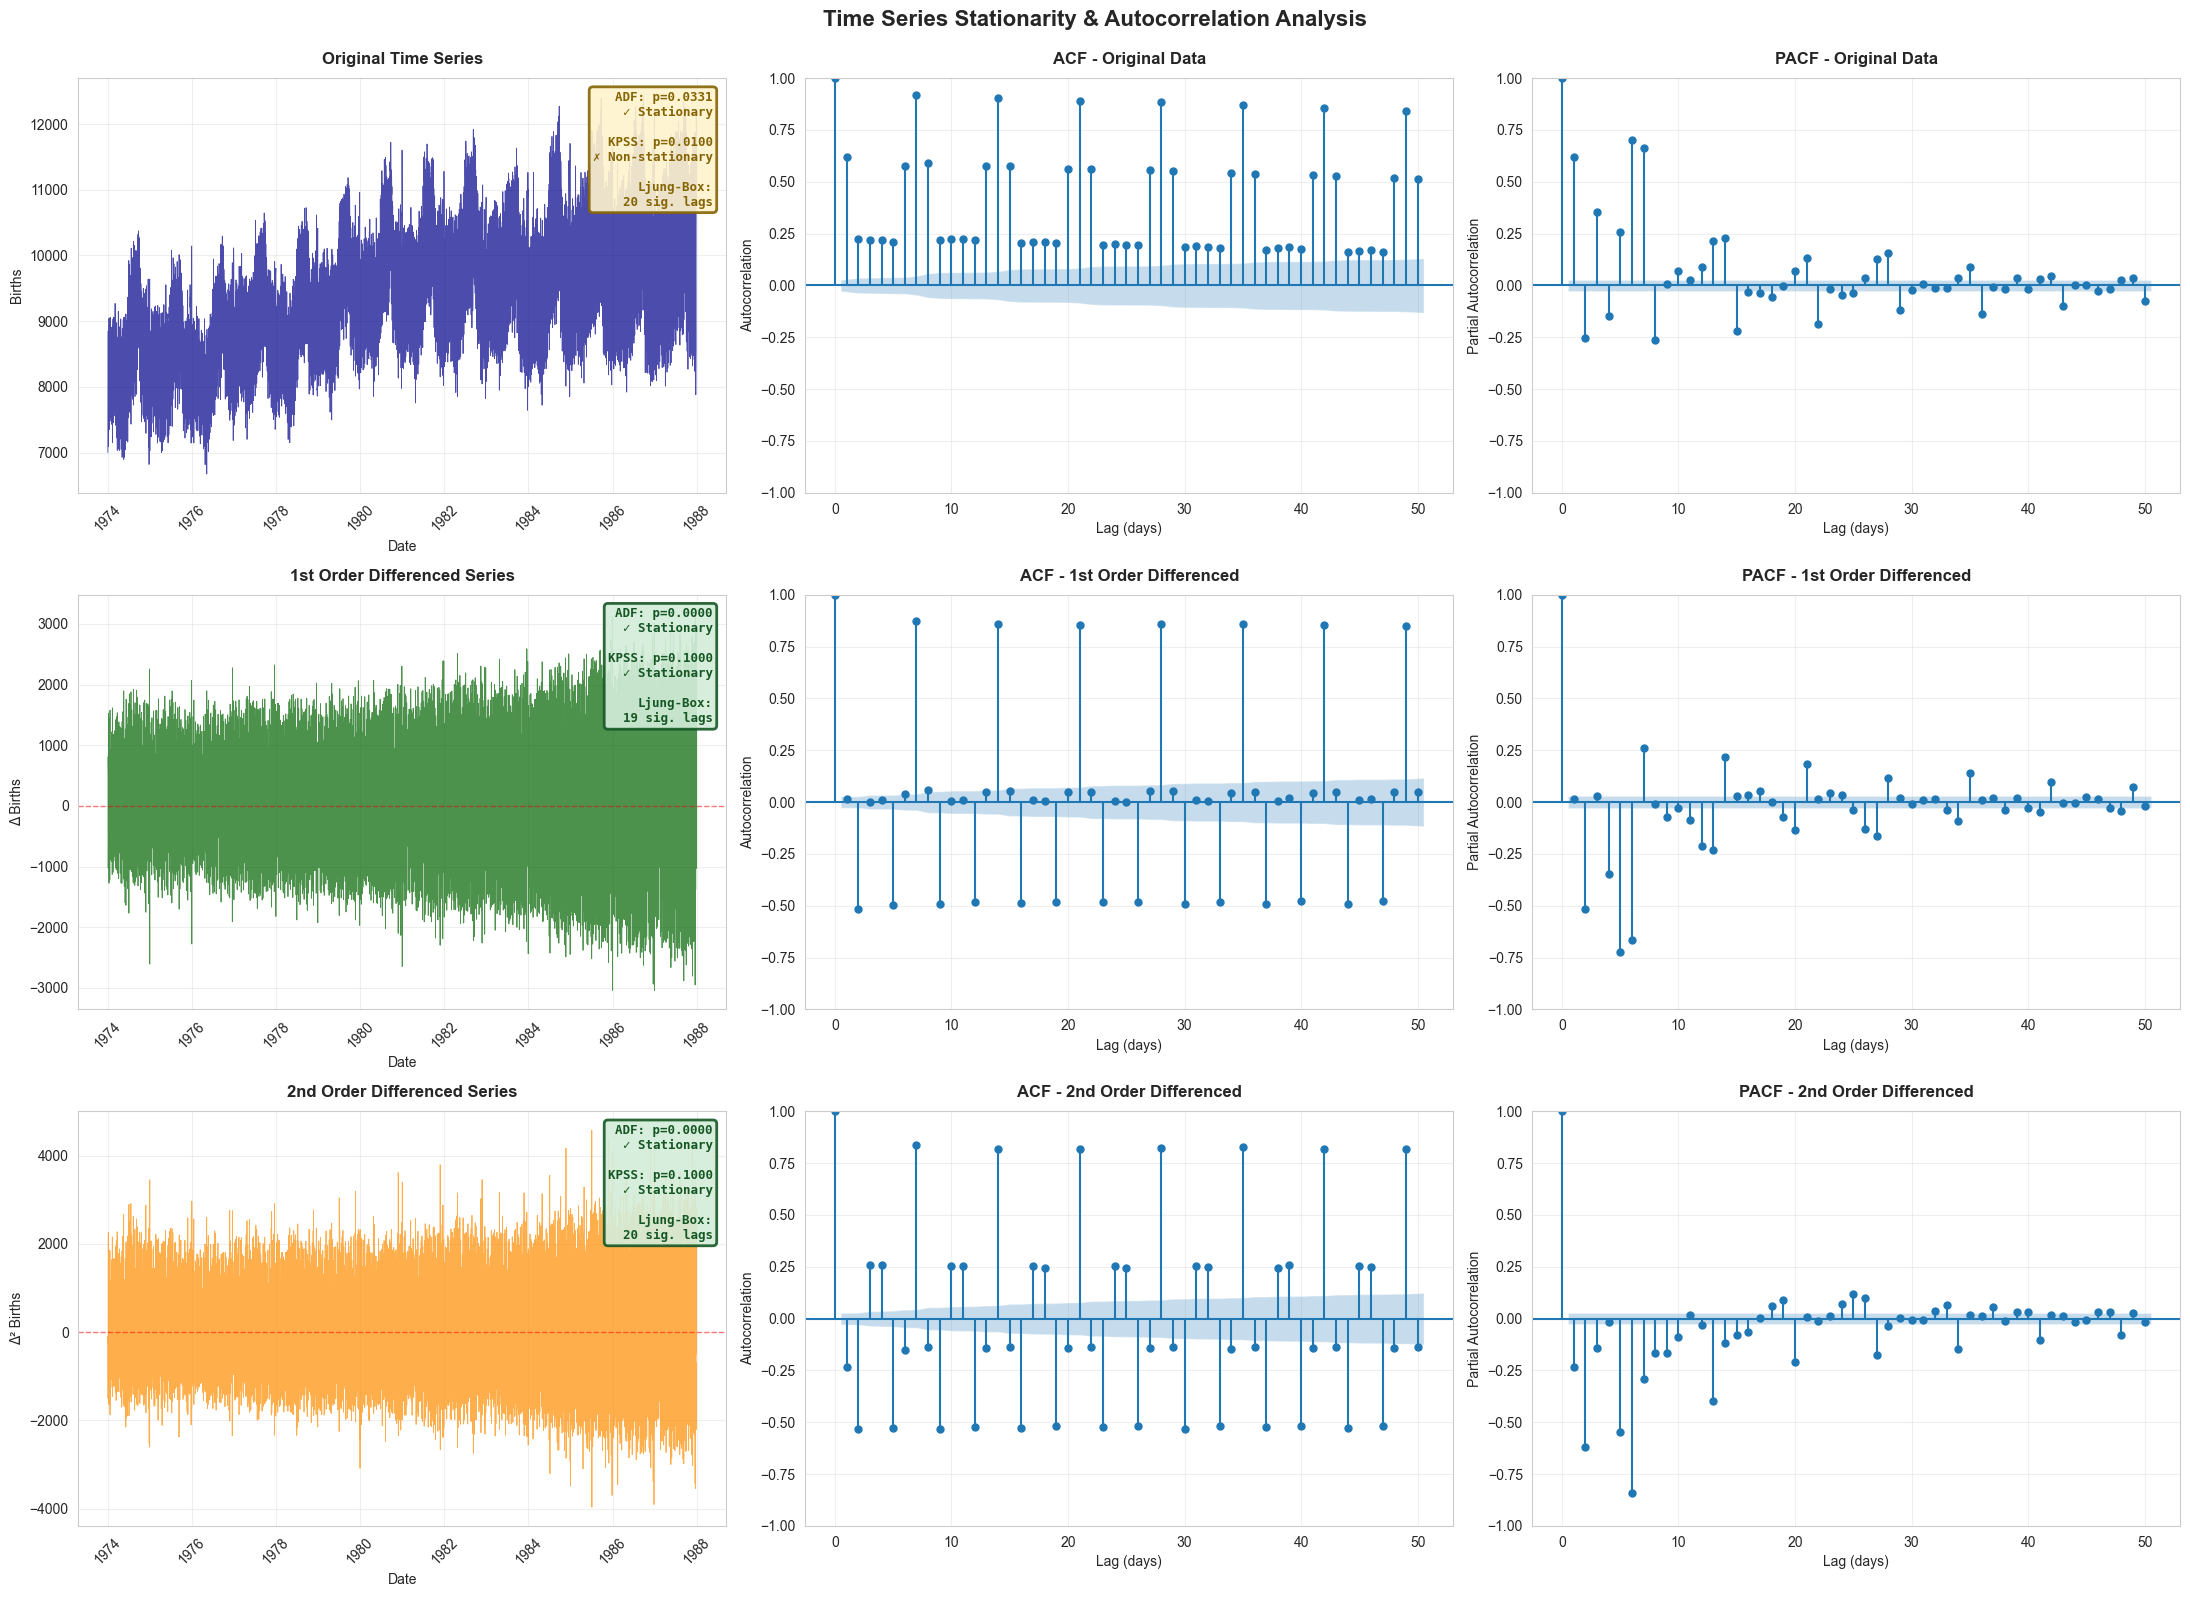


DESCRIPTIVE STATISTICS

Metric                    Original        1st Diff        2nd Diff       
----------------------------------------------------------------------
Mean                             9635.03       0.745305      -0.359617
Std Dev                          1126.30         983.98        1380.46
Variance                      1268547.42      968207.71     1905676.56
Min                              6675.00       -3045.00       -3964.00
Max                             12412.00        3171.00        4579.00
Observations                        5113           5112           5111

MODELING RECOMMENDATION

✓ RECOMMENDATION: Use d=1 (1st order differencing)
  → Both ADF and KPSS tests confirm stationarity after first differencing
  → This is the optimal differencing order for SARIMA modeling

KEY OBSERVATIONS FOR SARIMA PARAMETER SELECTION

1. DIFFERENCING (d):
   → d=1 achieves stationarity

2. AUTOREGRESSIVE ORDER (p):
   → Examine PACF cutoff points to determine AR order
   →

In [25]:
# ACF and PACF Analysis with Statistical Tests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

print("="*70)
print("STATIONARITY AND AUTOCORRELATION ANALYSIS")
print("="*70)

# Prepare data
original_data = analysis_data['births']
diff_1st = original_data.diff().dropna()
diff_2nd = original_data.diff().diff().dropna()

# Function to perform ADF test
def perform_adf_test(data):
    result = adfuller(data, autolag='AIC')
    return {
        'statistic': result[0],
        'pvalue': result[1],
        'critical_1%': result[4]['1%'],
        'critical_5%': result[4]['5%'],
        'stationary': result[1] < 0.05
    }

# Function to perform KPSS test
def perform_kpss_test(data):
    result = kpss(data, regression='ct', nlags='auto')
    return {
        'statistic': result[0],
        'pvalue': result[1],
        'critical_1%': result[3]['1%'],
        'critical_5%': result[3]['5%'],
        'stationary': result[1] > 0.05
    }

# Function to perform Ljung-Box test
def perform_ljungbox_test(data, lags=20):
    result = acorr_ljungbox(data, lags=lags, return_df=True)
    significant_lags = result[result['lb_pvalue'] < 0.05]
    return {
        'n_significant': len(significant_lags),
        'autocorrelated': len(significant_lags) > 0
    }

# Perform all tests
tests_original = {
    'adf': perform_adf_test(original_data),
    'kpss': perform_kpss_test(original_data),
    'lb': perform_ljungbox_test(original_data)
}

tests_1st = {
    'adf': perform_adf_test(diff_1st),
    'kpss': perform_kpss_test(diff_1st),
    'lb': perform_ljungbox_test(diff_1st)
}

tests_2nd = {
    'adf': perform_adf_test(diff_2nd),
    'kpss': perform_kpss_test(diff_2nd),
    'lb': perform_ljungbox_test(diff_2nd)
}

# Print summary to console
print("\n" + "="*70)
print("STATISTICAL TEST SUMMARY")
print("="*70)

def print_test_summary(name, tests):
    print(f"\n{name}:")
    print(f"  ADF Test: p-value = {tests['adf']['pvalue']:.6f} → {'Stationary' if tests['adf']['stationary'] else 'Non-stationary'}")
    print(f"  KPSS Test: p-value = {tests['kpss']['pvalue']:.6f} → {'Stationary' if tests['kpss']['stationary'] else 'Non-stationary'}")
    print(f"  Ljung-Box: {tests['lb']['n_significant']} significant lags → {'Autocorrelated' if tests['lb']['autocorrelated'] else 'No autocorrelation'}")

print_test_summary("Original Data", tests_original)
print_test_summary("1st Order Differenced", tests_1st)
print_test_summary("2nd Order Differenced", tests_2nd)
print("="*70)

# Create 3x3 figure
fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.suptitle('Time Series Stationarity & Autocorrelation Analysis',
             fontsize=16, fontweight='bold', y=0.995)

# Helper function to add test results as text box
def add_test_box(ax, tests, position='upper right'):
    adf_status = '✓ Stationary' if tests['adf']['stationary'] else '✗ Non-stationary'
    kpss_status = '✓ Stationary' if tests['kpss']['stationary'] else '✗ Non-stationary'

    textstr = f"ADF: p={tests['adf']['pvalue']:.4f}\n{adf_status}\n\n"
    textstr += f"KPSS: p={tests['kpss']['pvalue']:.4f}\n{kpss_status}\n\n"
    textstr += f"Ljung-Box:\n{tests['lb']['n_significant']} sig. lags"

    # Color based on stationarity
    if tests['adf']['stationary'] and tests['kpss']['stationary']:
        bbox_color = '#d4edda'  # light green
        text_color = '#155724'
    elif not tests['adf']['stationary'] and not tests['kpss']['stationary']:
        bbox_color = '#f8d7da'  # light red
        text_color = '#721c24'
    else:
        bbox_color = '#fff3cd'  # light yellow
        text_color = '#856404'

    props = dict(boxstyle='round', facecolor=bbox_color, alpha=0.9, edgecolor=text_color, linewidth=2)
    ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=props, fontfamily='monospace', color=text_color, fontweight='bold')

# ROW 1: Original Data
# Time series plot
axes[0, 0].plot(analysis_data['datetime'], original_data, linewidth=0.6, color='darkblue', alpha=0.7)
axes[0, 0].set_title('Original Time Series', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Date', fontsize=10)
axes[0, 0].set_ylabel('Births', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)
add_test_box(axes[0, 0], tests_original)

# ACF
plot_acf(original_data, lags=50, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title('ACF - Original Data', fontsize=12, fontweight='bold', pad=10)
axes[0, 1].set_xlabel('Lag (days)', fontsize=10)
axes[0, 1].set_ylabel('Autocorrelation', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# PACF
plot_pacf(original_data, lags=50, ax=axes[0, 2], alpha=0.05, method='ywm')
axes[0, 2].set_title('PACF - Original Data', fontsize=12, fontweight='bold', pad=10)
axes[0, 2].set_xlabel('Lag (days)', fontsize=10)
axes[0, 2].set_ylabel('Partial Autocorrelation', fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# ROW 2: 1st Order Differenced
# Time series plot
datetime_diff1 = analysis_data['datetime'].iloc[1:]
axes[1, 0].plot(datetime_diff1, diff_1st, linewidth=0.6, color='darkgreen', alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[1, 0].set_title('1st Order Differenced Series', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Date', fontsize=10)
axes[1, 0].set_ylabel('Δ Births', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)
add_test_box(axes[1, 0], tests_1st)

# ACF
plot_acf(diff_1st, lags=50, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF - 1st Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Lag (days)', fontsize=10)
axes[1, 1].set_ylabel('Autocorrelation', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# PACF
plot_pacf(diff_1st, lags=50, ax=axes[1, 2], alpha=0.05, method='ywm')
axes[1, 2].set_title('PACF - 1st Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[1, 2].set_xlabel('Lag (days)', fontsize=10)
axes[1, 2].set_ylabel('Partial Autocorrelation', fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

# ROW 3: 2nd Order Differenced
# Time series plot
datetime_diff2 = analysis_data['datetime'].iloc[2:]
axes[2, 0].plot(datetime_diff2, diff_2nd, linewidth=0.6, color='darkorange', alpha=0.7)
axes[2, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[2, 0].set_title('2nd Order Differenced Series', fontsize=12, fontweight='bold', pad=10)
axes[2, 0].set_xlabel('Date', fontsize=10)
axes[2, 0].set_ylabel('Δ² Births', fontsize=10)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].tick_params(axis='x', rotation=45)
add_test_box(axes[2, 0], tests_2nd)

# ACF
plot_acf(diff_2nd, lags=50, ax=axes[2, 1], alpha=0.05)
axes[2, 1].set_title('ACF - 2nd Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[2, 1].set_xlabel('Lag (days)', fontsize=10)
axes[2, 1].set_ylabel('Autocorrelation', fontsize=10)
axes[2, 1].grid(True, alpha=0.3)

# PACF
plot_pacf(diff_2nd, lags=50, ax=axes[2, 2], alpha=0.05, method='ywm')
axes[2, 2].set_title('PACF - 2nd Order Differenced', fontsize=12, fontweight='bold', pad=10)
axes[2, 2].set_xlabel('Lag (days)', fontsize=10)
axes[2, 2].set_ylabel('Partial Autocorrelation', fontsize=10)
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Descriptive Statistics Table
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)
print(f"\n{'Metric':<25} {'Original':<15} {'1st Diff':<15} {'2nd Diff':<15}")
print("-" * 70)
print(f"{'Mean':<25} {original_data.mean():>14.2f} {diff_1st.mean():>14.6f} {diff_2nd.mean():>14.6f}")
print(f"{'Std Dev':<25} {original_data.std():>14.2f} {diff_1st.std():>14.2f} {diff_2nd.std():>14.2f}")
print(f"{'Variance':<25} {original_data.var():>14.2f} {diff_1st.var():>14.2f} {diff_2nd.var():>14.2f}")
print(f"{'Min':<25} {original_data.min():>14.2f} {diff_1st.min():>14.2f} {diff_2nd.min():>14.2f}")
print(f"{'Max':<25} {original_data.max():>14.2f} {diff_1st.max():>14.2f} {diff_2nd.max():>14.2f}")
print(f"{'Observations':<25} {len(original_data):>14} {len(diff_1st):>14} {len(diff_2nd):>14}")
print("="*70)

# Final Recommendation
print("\n" + "="*70)
print("MODELING RECOMMENDATION")
print("="*70)

if tests_1st['adf']['stationary'] and tests_1st['kpss']['stationary']:
    print("\n✓ RECOMMENDATION: Use d=1 (1st order differencing)")
    print("  → Both ADF and KPSS tests confirm stationarity after first differencing")
    print("  → This is the optimal differencing order for SARIMA modeling")
elif tests_2nd['adf']['stationary'] and tests_2nd['kpss']['stationary']:
    print("\n✓ RECOMMENDATION: Use d=2 (2nd order differencing)")
    print("  → Data achieves stationarity only after second differencing")
    print("  → Use this order in SARIMA(p,d=2,q) models")
else:
    print("\n! RECOMMENDATION: Start with d=1 (standard approach)")
    print("  → Test results show mixed signals")
    print("  → Grid search will determine optimal differencing order")

print("\n" + "="*70)
print("KEY OBSERVATIONS FOR SARIMA PARAMETER SELECTION")
print("="*70)
print("\n1. DIFFERENCING (d):")
if tests_1st['adf']['stationary']:
    print("   → d=1 achieves stationarity")
else:
    print("   → Consider d=1 or d=2 based on grid search results")

print("\n2. AUTOREGRESSIVE ORDER (p):")
print("   → Examine PACF cutoff points to determine AR order")
print("   → Significant spikes suggest AR terms needed")

print("\n3. MOVING AVERAGE ORDER (q):")
print("   → Examine ACF cutoff points to determine MA order")
print("   → Gradual decay vs sharp cutoff indicates MA structure")

print("\n4. SEASONAL COMPONENTS (P, D, Q, s):")
print("   → Clear periodic patterns visible at lag 7 (weekly)")
print("   → Consider seasonal differencing (D=1) for removing seasonal trend")
print("   → Seasonal periods identified: 7, 183, 365 days")

print("="*70)

## 4. Fourier Analysis - Identify Dominant Frequencies


FOURIER ANALYSIS - FREQUENCY DOMAIN DECOMPOSITION


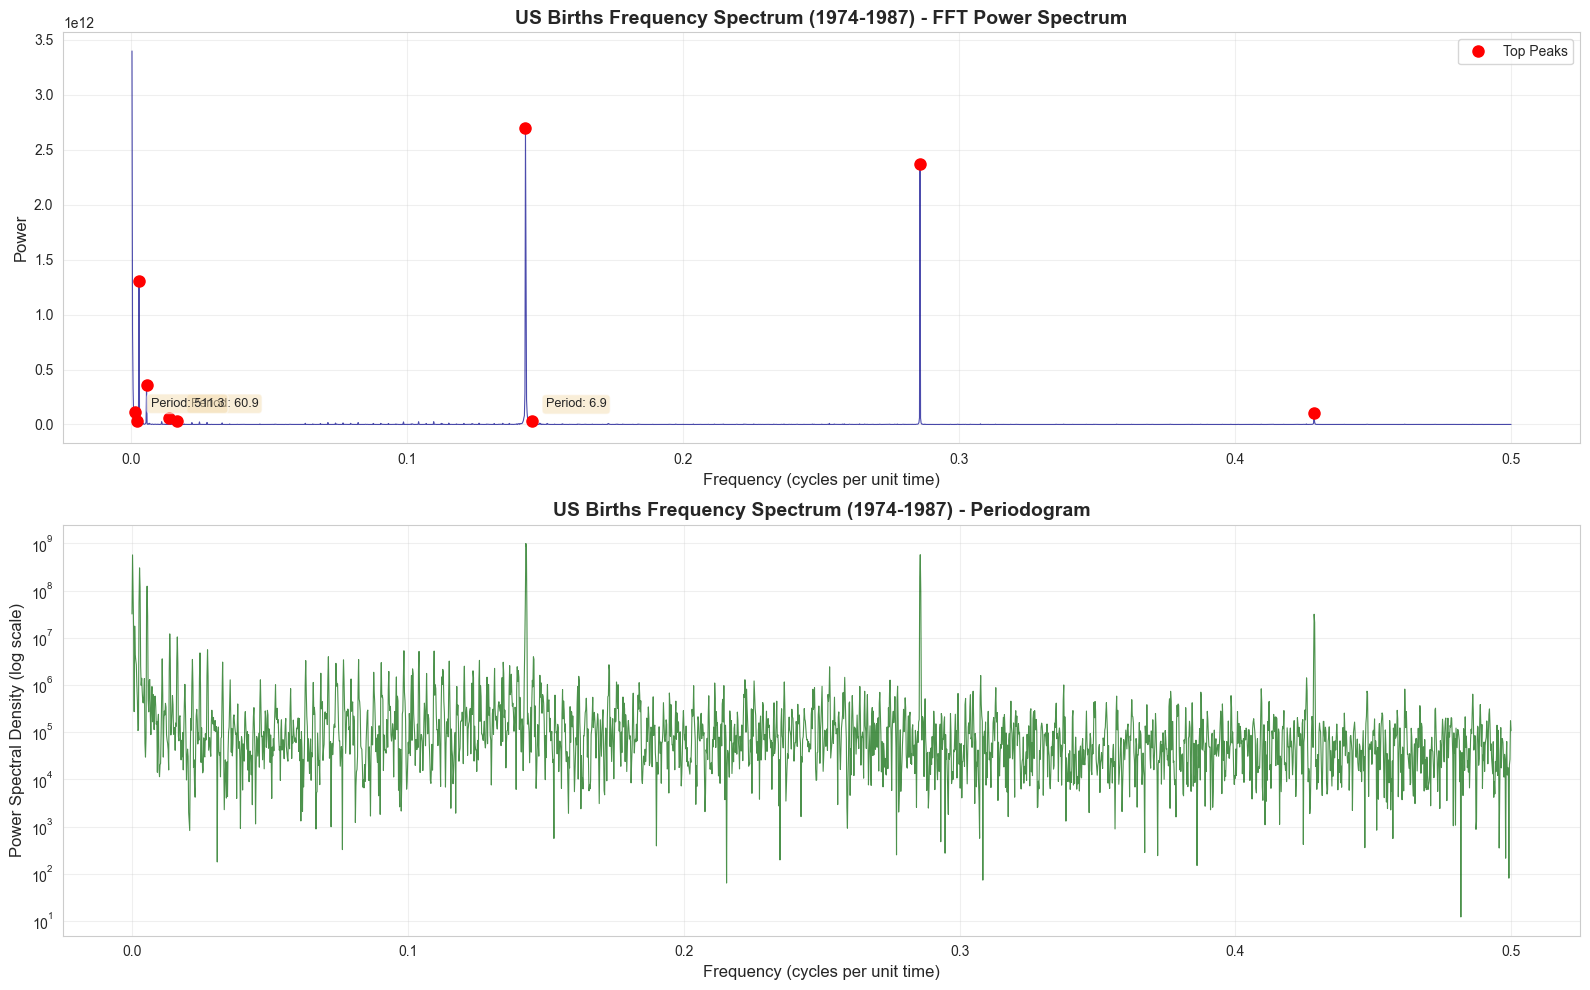

In [26]:
# Perform FFT and identify dominant frequencies
print("\n" + "="*70)
print("FOURIER ANALYSIS - FREQUENCY DOMAIN DECOMPOSITION")
print("="*70)

# Plot frequency spectrum with peak detection
fig = spectral.plot_frequency_spectrum(
    analysis_data['births'].values,
    sampling_rate=1.0,  # Daily data
    title='US Births Frequency Spectrum (1974-1987)',
    highlight_peaks=True,
    n_peaks=10
)
plt.show()

In [27]:
# Identify top seasonal periods
seasonal_periods_df = spectral.identify_seasonal_periods(
    analysis_data['births'].values,
    sampling_rate=1.0,
    n_periods=10
)

print("\nTop 10 Dominant Periods:")
print(seasonal_periods_df)


DOMINANT SEASONAL PERIODS
 rank     period  frequency        power interpretation
    1   7.004110   0.142773 2.696240e+12         Weekly
    2   3.499658   0.285742 2.370957e+12       3.5 days
    3 365.214286   0.002738 1.306143e+12         Annual
    4 182.607143   0.005476 3.592350e+11    Semi-annual
    5 730.428571   0.001369 1.096169e+11     730.4 days
    6   2.333638   0.428516 1.005929e+11       2.3 days
    7  73.042857   0.013691 5.990685e+10      73.0 days
    8 511.300000   0.001956 3.501021e+10     511.3 days
    9  60.869048   0.016429 3.477244e+10      60.9 days
   10   6.890836   0.145120 2.906850e+10         Weekly


Top 10 Dominant Periods:
   rank      period  frequency         power interpretation
0     1    7.004110   0.142773  2.696240e+12         Weekly
1     2    3.499658   0.285742  2.370957e+12       3.5 days
2     3  365.214286   0.002738  1.306143e+12         Annual
3     4  182.607143   0.005476  3.592350e+11    Semi-annual
4     5  730.428571   0.001369

In [28]:
# Extract top 4 periods for SARIMA modeling
top_4_periods = seasonal_periods_df.head(4)['period'].values
top_4_periods_int = [int(round(p)) for p in top_4_periods]

print("\n" + "="*70)
print("TOP 4 SEASONAL PERIODS FOR SARIMA MODELING")
print("="*70)
for i, period in enumerate(top_4_periods_int, 1):
    print(f"{i}. Period: {period} days")
print("="*70)


TOP 4 SEASONAL PERIODS FOR SARIMA MODELING
1. Period: 7 days
2. Period: 3 days
3. Period: 365 days
4. Period: 183 days


## 5. Wavelet Analysis - Time-Frequency Decomposition


WAVELET ANALYSIS - TIME-FREQUENCY REPRESENTATION

Computing wavelet transform...
  Scales: 200 (periods: 2.0 to 500.0 days)
  Wavelet: Morlet
✓ Wavelet transform complete


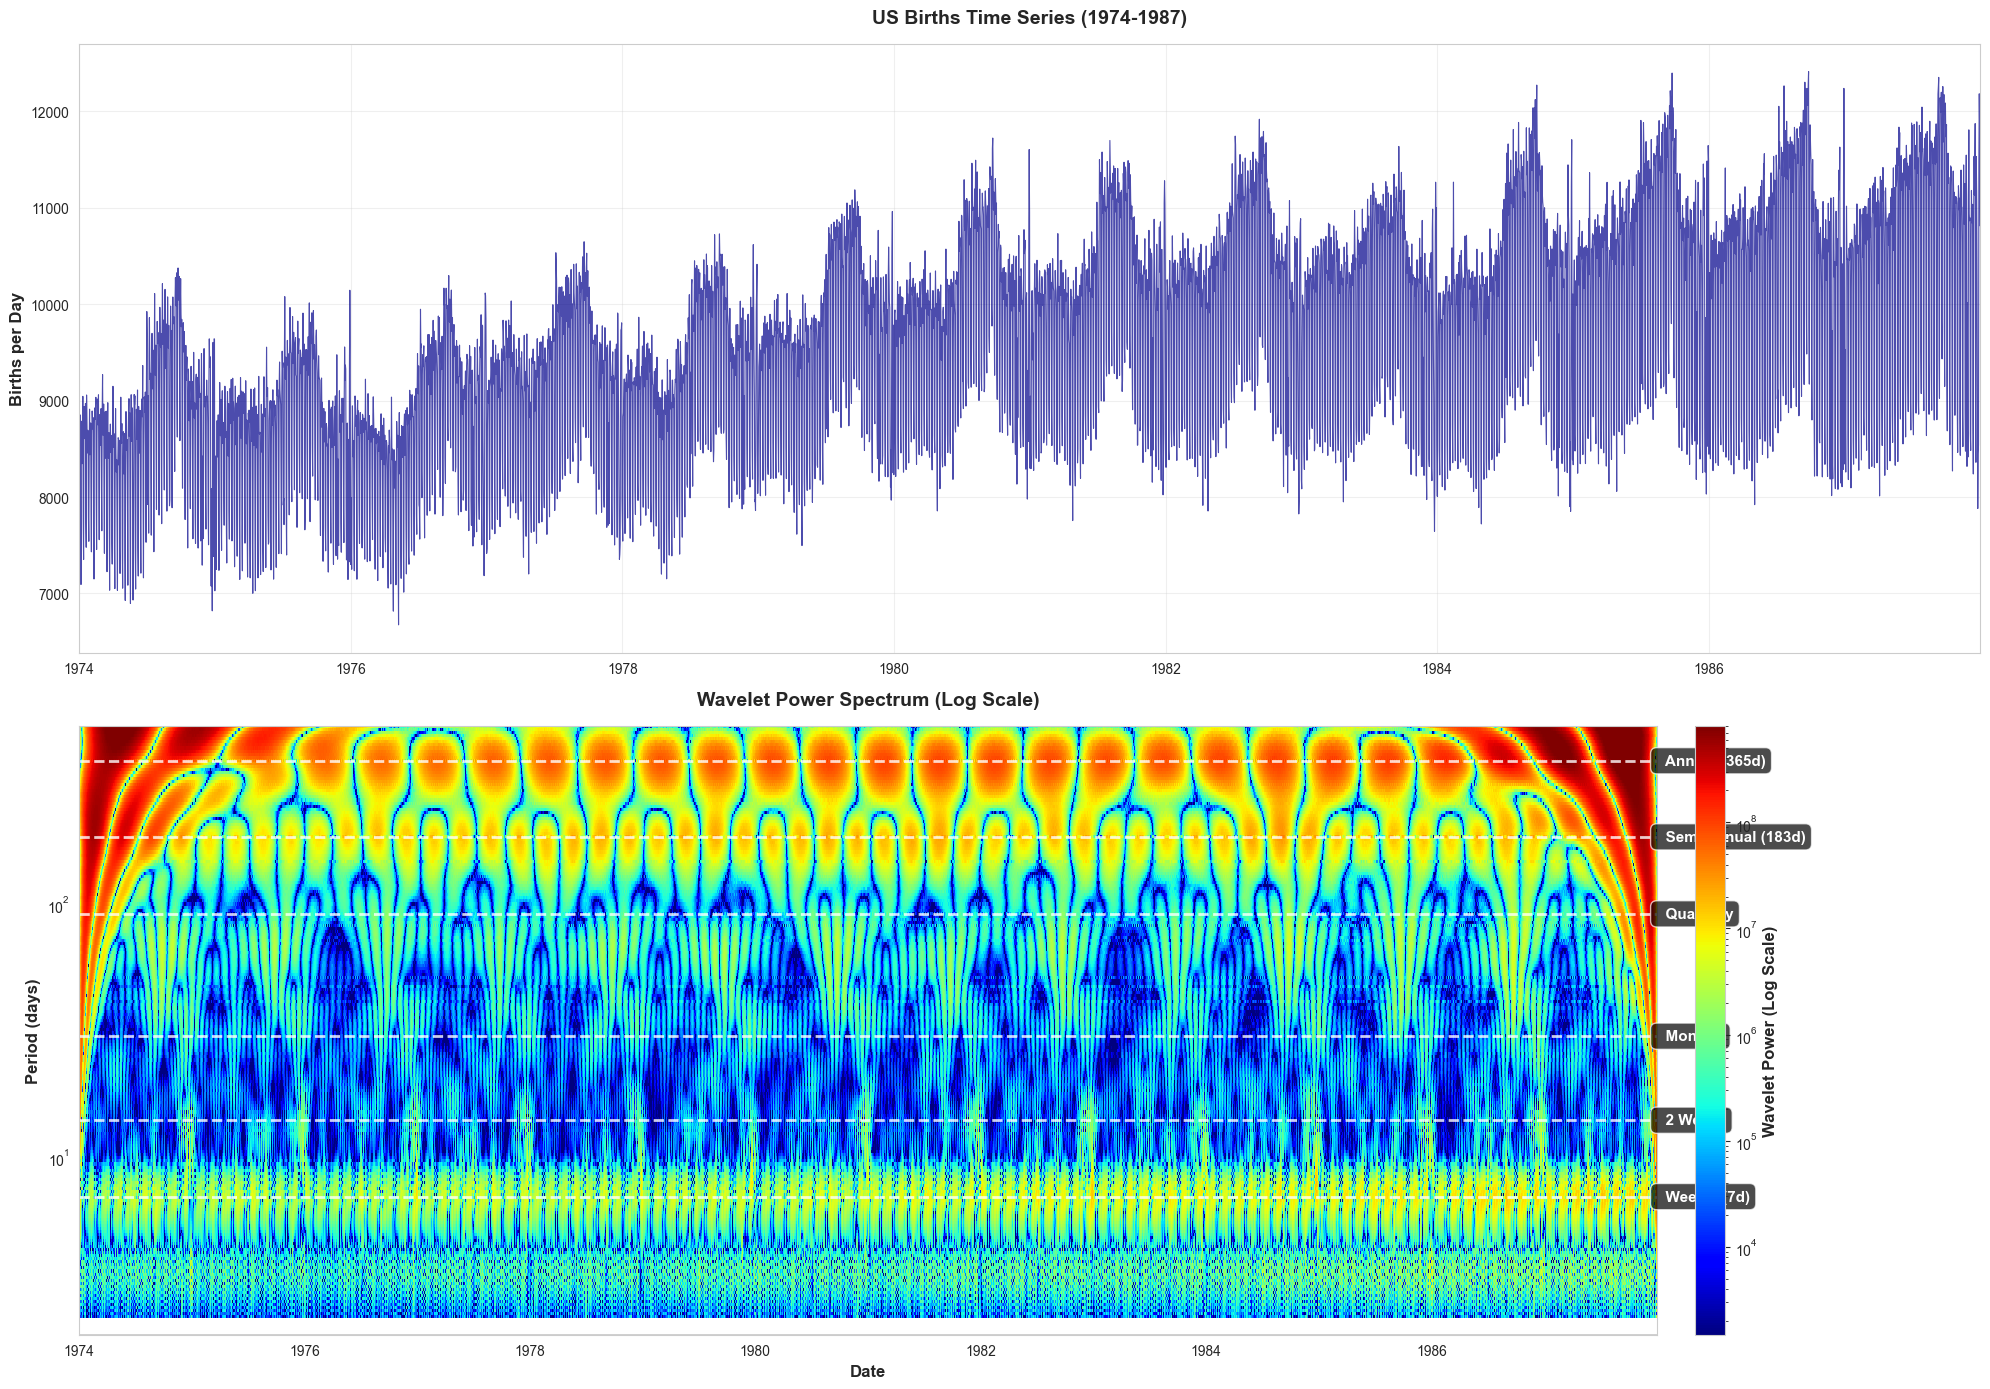


SCALOGRAM INTERPRETATION GUIDE

Color Coding (Log Scale):
  🔴 RED    = Strongest oscillations (high power)
  🟡 YELLOW = Strong oscillations
  🟢 GREEN  = Moderate oscillations
  🔵 BLUE   = Weak oscillations (low power)

What to Look For:
  • HORIZONTAL RED BANDS = Consistent periodic patterns over time
  • VERTICAL RED PATTERNS = Transient events or changes
  • Check the labeled periods:
    - 7 days: Weekly pattern (weekday/weekend effect)
    - 183 days: Semi-annual pattern
    - 365 days: Annual seasonal cycle

Key Observations:
  Average power at 7-day period: 3.61e+06
  Average power at 183-day period: 2.37e+07
  Average power at 365-day period: 1.01e+08



In [ ]:
# Continuous Wavelet Transform - Scalogram with Proper Scaling
print("\n" + "="*70)
print("WAVELET ANALYSIS - TIME-FREQUENCY REPRESENTATION")
print("="*70)

import pywt
from matplotlib.colors import LogNorm

# Prepare data
data = analysis_data['births'].values

# Define scales to cover periods from 2 days to 500 days
# For Morlet wavelet, scale ≈ period / (4*pi) * omega0, where omega0 ≈ 6 for 'morl'
# So for period P, scale ≈ P * 0.477
periods = np.logspace(np.log10(2), np.log10(500), 200)  # 200 scales from 2 to 500 days
scales = periods / (2 * np.pi / 6)  # Convert periods to scales for Morlet wavelet

print(f"\nComputing wavelet transform...")
print(f"  Scales: {len(scales)} (periods: {periods.min():.1f} to {periods.max():.1f} days)")
print(f"  Wavelet: Morlet")

# Compute continuous wavelet transform
coefficients, frequencies = pywt.cwt(data, scales, 'morl', sampling_period=1.0)

# Calculate power (absolute value squared)
power = np.abs(coefficients) ** 2

# Convert frequencies to periods
periods_cwt = 1 / frequencies

print(f"✓ Wavelet transform complete")

# Create figure with better layout
fig, axes = plt.subplots(2, 1, figsize=(20, 14))

# Top plot: Original time series
axes[0].plot(analysis_data['datetime'], data, linewidth=0.8, color='darkblue', alpha=0.7)
axes[0].set_ylabel('Births per Day', fontsize=12, fontweight='bold')
axes[0].set_title('US Births Time Series (1974-1987)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(analysis_data['datetime'].iloc[0], analysis_data['datetime'].iloc[-1])

# Bottom plot: Scalogram with LOG SCALE for power (this is key!)
# Use log normalization to show the full dynamic range
vmin = np.percentile(power[power > 0], 5)   # 5th percentile of non-zero values
vmax = np.percentile(power, 99.5)            # 99.5th percentile

# Plot with pcolormesh for better rendering and LogNorm for colors
im = axes[1].pcolormesh(analysis_data['datetime'], periods_cwt, power,
                        cmap='jet',
                        norm=LogNorm(vmin=vmin, vmax=vmax),
                        shading='auto')

axes[1].set_ylabel('Period (days)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[1].set_title('Wavelet Power Spectrum (Log Scale)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_yscale('log')
axes[1].set_ylim([2, 500])

# Add gridlines
axes[1].grid(True, alpha=0.4, color='white', linestyle='--', linewidth=0.8)

# Add reference lines for key periods with labels
key_periods = {
    7: 'Weekly (7d)',
    14: '2 Weeks',
    30: 'Monthly',
    91: 'Quarterly',
    183: 'Semi-annual (183d)',
    365: 'Annual (365d)'
}

for period, label in key_periods.items():
    if 2 <= period <= 500:
        axes[1].axhline(y=period, color='white', linestyle='--', linewidth=2, alpha=0.8)
        # Add label on the right side
        axes[1].text(analysis_data['datetime'].iloc[-1], period, f'  {label}',
                    fontsize=11, color='white', fontweight='bold',
                    verticalalignment='center', horizontalalignment='left',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.7, edgecolor='white'))

# Add colorbar with proper label
cbar = plt.colorbar(im, ax=axes[1], pad=0.02)
cbar.set_label('Wavelet Power (Log Scale)', fontsize=12, fontweight='bold')

# Add cone of influence (optional - shows edge effects)
# Cone of influence for Morlet wavelet is approximately sqrt(2) * scale
coi = periods_cwt * np.sqrt(2)
axes[1].fill_between(analysis_data['datetime'], 0, 2,
                     color='gray', alpha=0.3, label='Edge effects')

plt.tight_layout()
plt.show()

# Print interpretation guide
print("\n" + "="*70)
print("SCALOGRAM INTERPRETATION GUIDE")
print("="*70)
print("\nColor Coding (Log Scale):")
print("  🔴 RED    = Strongest oscillations (high power)")
print("  🟡 YELLOW = Strong oscillations")
print("  🟢 GREEN  = Moderate oscillations")
print("  🔵 BLUE   = Weak oscillations (low power)")

print("\nWhat to Look For:")
print("  • HORIZONTAL RED BANDS = Consistent periodic patterns over time")
print("  • VERTICAL RED PATTERNS = Transient events or changes")
print("  • Check the labeled periods:")
print(f"    - 7 days: Weekly pattern (weekday/weekend effect)")
print(f"    - 183 days: Semi-annual pattern")
print(f"    - 365 days: Annual seasonal cycle")

print("\nKey Observations:")
# Calculate average power at key periods
idx_7d = np.argmin(np.abs(periods_cwt - 7))
idx_183d = np.argmin(np.abs(periods_cwt - 183))
idx_365d = np.argmin(np.abs(periods_cwt - 365))

avg_power_7d = np.mean(power[idx_7d, :])
avg_power_183d = np.mean(power[idx_183d, :])
avg_power_365d = np.mean(power[idx_365d, :])

print(f"  Average power at 7-day period: {avg_power_7d:.2e}")
print(f"  Average power at 183-day period: {avg_power_183d:.2e}")
print(f"  Average power at 365-day period: {avg_power_365d:.2e}")

print("\n" + "="*70)

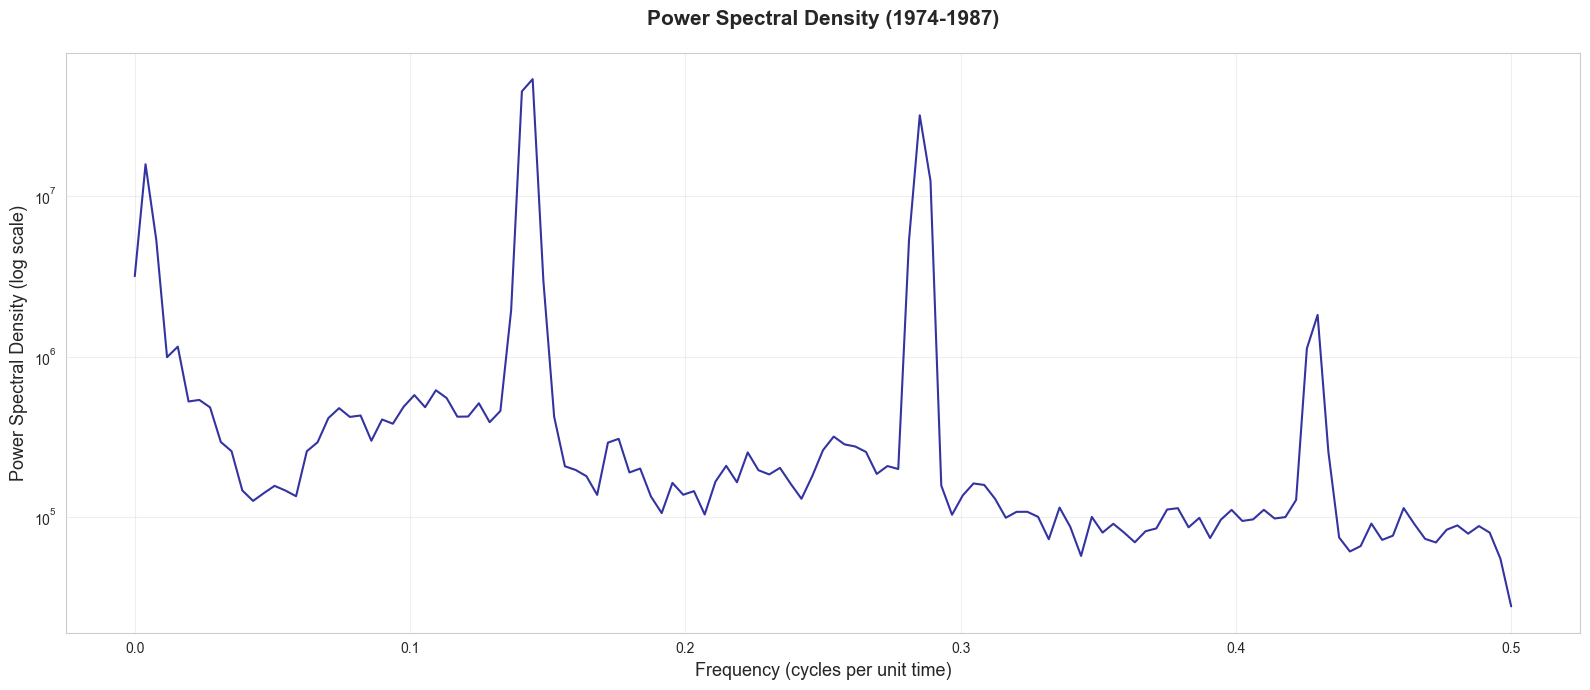

In [30]:
# Power Spectral Density for confirmation
fig = spectral.plot_psd(
    analysis_data['births'].values,
    sampling_rate=1.0,
    title='Power Spectral Density (1974-1987)'
)
plt.show()

## 6. Train/Test Split

Train: 1974-1986 (13 years)
Test: 1987 (1 year)

In [31]:
# Split by date: train on 1974-1986, test on 1987
train_df, test_df = tsub.split_train_test(
    analysis_data,
    datetime_col='datetime',
    test_size=365,  # 1987 has 365 days
    by_date=False
)

print(f"Training period: {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Testing period: {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")


TRAIN/TEST SPLIT
Train set: 4748 observations
  Start: 1974-01-01 00:00:00
  End:   1986-12-31 00:00:00

Test set: 365 observations
  Start: 1987-01-01 00:00:00
  End:   1987-12-31 00:00:00

Training period: 1974-01-01 to 1986-12-31
Testing period: 1987-01-01 to 1987-12-31


## 7. SARIMA Modeling Based on Top 4 Fourier Frequencies

We'll fit SARIMA models using the seasonal periods identified by Fourier analysis

In [230]:
# Fit SARIMAX Model with Multiple Seasonalities
# Weekly seasonality (7 days) via SARIMA seasonal component
# Semi-annual (183 days) and Annual (365 days) seasonality via Fourier terms
# US Federal Holidays as exogenous binary indicators

import time
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*70)
print("FITTING SARIMAX MODEL WITH MULTIPLE SEASONALITIES")
print("="*70)
print("\nModel Configuration:")
print("  SARIMA Order: (2, 1, 4)")
print("  Seasonal Order: (1, 1, 1, 7) - Weekly seasonality")
print("  Fourier Terms:")
print("    • Semi-annual (183 days): harmonics")
print("    • Annual (365 days): harmonics")
print("  Holiday Indicators:")
print("    • US Federal Holidays (binary)")
print("\nRationale:")
print("  • SARIMA handles short-period seasonality (7 days) efficiently")
print("  • Fourier terms handle long-period seasonality without huge computational cost")
print("  • Holiday indicators capture abnormal birth rate drops")
print("  • Fourier analysis identified weekly, semi-annual, and annual patterns")
print("="*70)

# Create Fourier terms for annual and semi-annual seasonality
def create_fourier_terms(dates, period, n_harmonics):
    """
    Create Fourier terms for seasonal modeling

    Parameters:
    -----------
    dates : array-like
        Time indices (e.g., 0, 1, 2, ...)
    period : float
        Seasonal period in same units as dates
    n_harmonics : int
        Number of Fourier term pairs (sin/cos)

    Returns:
    --------
    DataFrame with Fourier terms
    """
    fourier_terms = {}
    t = np.arange(len(dates))

    for k in range(1, n_harmonics + 1):
        fourier_terms[f'sin_{period}_{k}'] = np.sin(2 * np.pi * k * t / period)
        fourier_terms[f'cos_{period}_{k}'] = np.cos(2 * np.pi * k * t / period)

    return pd.DataFrame(fourier_terms)

# Create US Federal Holiday indicators
def create_holiday_indicators(dates):
    """
    Create binary indicators for US Federal Holidays

    Parameters:
    -----------
    dates : DatetimeIndex or Series
        Dates to check for holidays

    Returns:
    --------
    DataFrame with holiday indicator (integer index for alignment)
    """
    from pandas.tseries.holiday import USFederalHolidayCalendar

    cal = USFederalHolidayCalendar()

    # Get holidays for the date range
    holidays = cal.holidays(start=dates.min(), end=dates.max())

    # Create binary indicator: 1 if holiday, 0 otherwise
    is_holiday = dates.isin(holidays).astype(int)

    # Return DataFrame with integer index (no datetime index to avoid alignment issues)
    return pd.DataFrame({'is_holiday': is_holiday.values})

# Generate Fourier terms for training data
print("\n" + "-"*70)
print("Generating Fourier terms and holiday indicators...")

n_harmonics_annual = 2
n_harmonics_semi = 2

# Annual seasonality (365.25 days)
fourier_train_annual = create_fourier_terms(
    train_df['datetime'],
    period=365.25,
    n_harmonics=n_harmonics_annual
)

# Semi-annual seasonality (182.625 days)
fourier_train_semi = create_fourier_terms(
    train_df['datetime'],
    period=182.625,
    n_harmonics=n_harmonics_semi
)

# Holiday indicators for training
holiday_train = create_holiday_indicators(train_df['datetime'])

# Combine Fourier terms and holiday indicators
fourier_train = pd.concat([fourier_train_annual, fourier_train_semi, holiday_train], axis=1)

# Reset index to ensure no NaN issues
fourier_train = fourier_train.reset_index(drop=True)

print(f"✓ Training exogenous features: {fourier_train.shape[1]} total")
print(f"  • Annual (365 days): {n_harmonics_annual} harmonics = {n_harmonics_annual*2} terms")
print(f"  • Semi-annual (183 days): {n_harmonics_semi} harmonics = {n_harmonics_semi*2} terms")
print(f"  • US Federal Holidays: 1 binary indicator")
print(f"  • Holidays in training set: {holiday_train['is_holiday'].sum()} days")

# Check for NaN or inf values
if fourier_train.isnull().any().any():
    print("⚠️  WARNING: NaN values detected in training features!")
    print(fourier_train.isnull().sum())
if np.isinf(fourier_train.values).any():
    print("⚠️  WARNING: Inf values detected in training features!")

# Generate Fourier terms and holiday indicators for test data
fourier_test_annual = create_fourier_terms(
    test_df['datetime'],
    period=365.25,
    n_harmonics=n_harmonics_annual
)

fourier_test_semi = create_fourier_terms(
    test_df['datetime'],
    period=182.625,
    n_harmonics=n_harmonics_semi
)

# Holiday indicators for test
holiday_test = create_holiday_indicators(test_df['datetime'])

fourier_test = pd.concat([fourier_test_annual, fourier_test_semi, holiday_test], axis=1)

# Reset index to ensure no NaN issues
fourier_test = fourier_test.reset_index(drop=True)

print(f"✓ Test exogenous features: {fourier_test.shape[1]} total")
print(f"  • Holidays in test set: {holiday_test['is_holiday'].sum()} days")
print("-"*70)

# Fit SARIMAX model with progress indicator
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("\nFitting SARIMAX(2,1,4)×(1,1,1,7) with Fourier terms + Holiday indicators...")

# Progress tracking
start_time = time.time()
stop_progress = False
fitting_complete = False

def show_progress():
    """Display animated progress while model fits"""
    import sys
    symbols = ['⠋', '⠙', '⠹', '⠸', '⠼', '⠴', '⠦', '⠧', '⠇', '⠏']
    idx = 0

    while not stop_progress:
        elapsed = time.time() - start_time
        mins = int(elapsed // 60)
        secs = int(elapsed % 60)

        # Create progress bar (simulated based on time)
        bar_length = 40
        progress = min(elapsed / 30, 1.0)  # Estimate 30 sec completion
        filled = int(bar_length * progress)
        bar = '█' * filled + '░' * (bar_length - filled)
        percentage = int(progress * 100)

        sys.stdout.write(f'\r{symbols[idx]} Fitting model... [{bar}] {percentage}% | Elapsed: {mins:02d}:{secs:02d}')
        sys.stdout.flush()

        idx = (idx + 1) % len(symbols)
        time.sleep(0.1)

    if fitting_complete:
        elapsed = time.time() - start_time
        mins = int(elapsed // 60)
        secs = int(elapsed % 60)
        bar = '█' * bar_length
        sys.stdout.write(f'\r✓ Model fitted!   [{bar}] 100% | Total time: {mins:02d}:{secs:02d}\n')
        sys.stdout.flush()

# Start progress indicator in background thread
import threading
progress_thread = threading.Thread(target=show_progress, daemon=True)
progress_thread.start()

try:
    # Define model orders
    order = (2, 1, 4)
    seasonal_order = (1, 1, 1, 7)

    # Initialize SARIMAX model with Fourier terms + holidays as exogenous variables
    model = SARIMAX(
        train_df['births'],
        exog=fourier_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=True,  # More stable
        enforce_invertibility=True   # Avoid numerical issues
    )

    # Fit the model
    best_sarima_fitted = model.fit(disp=False, maxiter=200)

    fitting_complete = True
    stop_progress = True
    progress_thread.join(timeout=1)

except Exception as e:
    stop_progress = True
    progress_thread.join(timeout=1)
    print(f"\n\n❌ Error fitting model: {str(e)}")
    import traceback
    traceback.print_exc()
    raise

# Calculate total time
total_time = time.time() - start_time
mins = int(total_time // 60)
secs = int(total_time % 60)

print("-"*70)
print(f"\n⏱️  Total fitting time: {mins} min {secs} sec")

# Extract model info
aic = best_sarima_fitted.aic
bic = best_sarima_fitted.bic
hqic = best_sarima_fitted.hqic

# Calculate in-sample metrics
fitted_values = best_sarima_fitted.fittedvalues
residuals = best_sarima_fitted.resid
mse = np.mean(residuals**2)
rmse = np.sqrt(mse)

# Get holiday coefficient to see impact
holiday_coef = best_sarima_fitted.params['is_holiday'] if 'is_holiday' in best_sarima_fitted.params else None

# Store results for comparison
sarima_model_results = [{
    'period': '7 + 183 + 365 + Holidays (SARIMAX+Fourier)',
    'interpretation': 'Multiple Seasonality + Holidays',
    'p': order[0],
    'd': order[1],
    'q': order[2],
    'P': seasonal_order[0],
    'D': seasonal_order[1],
    'Q': seasonal_order[2],
    'AIC': aic,
    'BIC': bic,
    'HQIC': hqic
}]

print("\n" + "="*70)
print("SARIMAX MODEL FITTING COMPLETE")
print("="*70)
print(f"\nModel Specification:")
print(f"  SARIMA Order: (p={order[0]}, d={order[1]}, q={order[2]})")
print(f"  Seasonal Order: (P={seasonal_order[0]}, D={seasonal_order[1]}, Q={seasonal_order[2]}, s={seasonal_order[3]})")
print(f"\nSeasonality Components:")
print(f"  ✓ Weekly (7-day) - via SARIMA seasonal component")
print(f"  ✓ Semi-annual (183-day) - via {n_harmonics_semi} Fourier harmonics")
print(f"  ✓ Annual (365-day) - via {n_harmonics_annual} Fourier harmonics")
print(f"  ✓ US Federal Holidays - binary indicator")

print(f"\nModel Quality Metrics:")
print(f"  AIC:  {aic:.2f}")
print(f"  BIC:  {bic:.2f}")
print(f"  HQIC: {hqic:.2f}")
print(f"  RMSE (in-sample): {rmse:.2f}")

print(f"\nModel Parameters:")
print(f"  Total parameters: {len(best_sarima_fitted.params)}")
print(f"    • ARIMA parameters: {order[0] + order[2]}")
print(f"    • Seasonal parameters: {seasonal_order[0] + seasonal_order[2]}")
print(f"    • Fourier terms: {fourier_train.shape[1] - 1}")  # -1 for holiday
print(f"    • Holiday indicator: 1")

if holiday_coef is not None:
    print(f"\nHoliday Effect:")
    print(f"  • Coefficient: {holiday_coef:.2f}")
    if holiday_coef < 0:
        print(f"  • Impact: Reduces births by ~{abs(holiday_coef):.0f} on holidays")
    else:
        print(f"  • Impact: Increases births by ~{holiday_coef:.0f} on holidays")

print(f"\nConvergence:")
if hasattr(best_sarima_fitted, 'mle_retvals'):
    if best_sarima_fitted.mle_retvals['converged']:
        print(f"  ✓ Model converged successfully")
    else:
        print(f"  ⚠ Model did not converge")
print("="*70)

# Prepare data for downstream cells
prophet_train = pd.DataFrame({
    'ds': train_df['datetime'],
    'y': train_df['births']
})

prophet_test = pd.DataFrame({
    'ds': test_df['datetime']
})

# Store residuals for diagnostics
residuals_train = residuals.values


FITTING SARIMAX MODEL WITH MULTIPLE SEASONALITIES

Model Configuration:
  SARIMA Order: (2, 1, 4)
  Seasonal Order: (1, 1, 1, 7) - Weekly seasonality
  Fourier Terms:
    • Semi-annual (183 days): harmonics
    • Annual (365 days): harmonics
  Holiday Indicators:
    • US Federal Holidays (binary)

Rationale:
  • SARIMA handles short-period seasonality (7 days) efficiently
  • Fourier terms handle long-period seasonality without huge computational cost
  • Holiday indicators capture abnormal birth rate drops
  • Fourier analysis identified weekly, semi-annual, and annual patterns

----------------------------------------------------------------------
Generating Fourier terms and holiday indicators...
✓ Training exogenous features: 9 total
  • Annual (365 days): 2 harmonics = 4 terms
  • Semi-annual (183 days): 2 harmonics = 4 terms
  • US Federal Holidays: 1 binary indicator
  • Holidays in training set: 118 days
✓ Test exogenous features: 9 total
  • Holidays in test set: 10 days
---

In [231]:
# Display Model Summary
comparison_df = pd.DataFrame(sarima_model_results)

print("\n" + "="*70)
print("SELECTED SARIMA MODEL SUMMARY")
print("="*70)
print("\nModel Specification:")
print(f"  SARIMA({comparison_df.iloc[0]['p']},{comparison_df.iloc[0]['d']},{comparison_df.iloc[0]['q']})×({comparison_df.iloc[0]['P']},{comparison_df.iloc[0]['D']},{comparison_df.iloc[0]['Q']},{comparison_df.iloc[0]['period']})")
print(f"\nSeasonal Period: {comparison_df.iloc[0]['period']} days ({comparison_df.iloc[0]['interpretation']})")
print(f"\nModel Quality Metrics:")
print(f"  AIC:  {comparison_df.iloc[0]['AIC']:.2f}")
print(f"  BIC:  {comparison_df.iloc[0]['BIC']:.2f}")
print(f"  HQIC: {comparison_df.iloc[0]['HQIC']:.2f}")
print("\n" + "="*70)


SELECTED SARIMA MODEL SUMMARY

Model Specification:
  SARIMA(2,1,4)×(1,1,1,7 + 183 + 365 + Holidays (SARIMAX+Fourier))

Seasonal Period: 7 + 183 + 365 + Holidays (SARIMAX+Fourier) days (Multiple Seasonality + Holidays)

Model Quality Metrics:
  AIC:  65932.43
  BIC:  66048.78
  HQIC: 65973.32



## 8. Model Summary and Configuration

In [232]:
# Extract model configuration for downstream use
best_model_info = comparison_df.iloc[0]

print("\n" + "="*70)
print("MODEL CONFIGURATION FOR ANALYSIS")
print("="*70)
print(f"\nModel: SARIMAX with Multiple Seasonalities + Holidays")
print(f"\nSARIMA Component:")
print(f"  Order: (p={order[0]}, d={order[1]}, q={order[2]})")
print(f"  Seasonal: (P={seasonal_order[0]}, D={seasonal_order[1]}, Q={seasonal_order[2]}, s={seasonal_order[3]})")
print(f"\nExogenous Variables Strategy:")
print(f"  1. Weekly (7-day): SARIMA seasonal component")
print(f"     • Efficient for short-period seasonality")
print(f"     • Captures weekday/weekend patterns")
print(f"\n  2. Semi-annual (183-day): {n_harmonics_semi} Fourier harmonics")
print(f"     • {n_harmonics_semi*2} terms (sin/cos pairs)")
print(f"     • Models bi-modal annual pattern")
print(f"\n  3. Annual (365-day): {n_harmonics_annual} Fourier harmonics")
print(f"     • {n_harmonics_annual*2} terms (sin/cos pairs)")
print(f"     • Captures yearly seasonal cycle")
print(f"\n  4. US Federal Holidays: Binary indicator")
print(f"     • 1 term (0 or 1)")
print(f"     • Captures abnormal drops in births on holidays")
print(f"\nTotal Exogenous Features: {fourier_train.shape[1]}")
print(f"  • Annual Fourier terms: {n_harmonics_annual*2}")
print(f"  • Semi-annual Fourier terms: {n_harmonics_semi*2}")
print(f"  • Holiday indicator: 1")
print(f"\nKey Advantages:")
print(f"  • SARIMA handles weekly seasonality efficiently")
print(f"  • Fourier terms avoid computational cost of long seasonal periods")
print(f"  • Holiday indicators capture special calendar events")
print(f"  • Flexible representation of complex patterns")
print(f"  • Better than single-seasonality SARIMA for multi-scale data")
print(f"\nModel already fitted in previous cell")
print("="*70)

# Set for downstream compatibility
best_order = order
best_seasonal = seasonal_order


MODEL CONFIGURATION FOR ANALYSIS

Model: SARIMAX with Multiple Seasonalities + Holidays

SARIMA Component:
  Order: (p=2, d=1, q=4)
  Seasonal: (P=1, D=1, Q=1, s=7)

Exogenous Variables Strategy:
  1. Weekly (7-day): SARIMA seasonal component
     • Efficient for short-period seasonality
     • Captures weekday/weekend patterns

  2. Semi-annual (183-day): 2 Fourier harmonics
     • 4 terms (sin/cos pairs)
     • Models bi-modal annual pattern

  3. Annual (365-day): 2 Fourier harmonics
     • 4 terms (sin/cos pairs)
     • Captures yearly seasonal cycle

  4. US Federal Holidays: Binary indicator
     • 1 term (0 or 1)
     • Captures abnormal drops in births on holidays

Total Exogenous Features: 9
  • Annual Fourier terms: 4
  • Semi-annual Fourier terms: 4
  • Holiday indicator: 1

Key Advantages:
  • SARIMA handles weekly seasonality efficiently
  • Fourier terms avoid computational cost of long seasonal periods
  • Holiday indicators capture special calendar events
  • Flexible 

In [233]:
# Model is already fitted as best_sarima_fitted (SARIMAX model) in cell 20
# Display SARIMAX model convergence and diagnostic information

print("\n" + "="*70)
print("SARIMAX MODEL CONVERGENCE AND FIT")
print("="*70)

# Check convergence
if hasattr(best_sarima_fitted, 'mle_retvals'):
    if best_sarima_fitted.mle_retvals['converged']:
        print(f"✓ Model converged successfully")
        print(f"  Iterations: {best_sarima_fitted.mle_retvals.get('iterations', 'N/A')}")
    else:
        print(f"⚠ Model did not converge")
else:
    print(f"✓ Model fitting complete")

# Display model summary statistics
print(f"\nModel Components:")
print(f"  • ARIMA: ({order[0]}, {order[1]}, {order[2]})")
print(f"  • Seasonal ARIMA: ({seasonal_order[0]}, {seasonal_order[1]}, {seasonal_order[2]}, {seasonal_order[3]})")
print(f"  • Exogenous variables: {fourier_train.shape[1]} Fourier terms")

# Parameter counts
n_ar_params = order[0]
n_ma_params = order[2]
n_seasonal_ar = seasonal_order[0]
n_seasonal_ma = seasonal_order[2]
n_fourier = fourier_train.shape[1]
total_params = len(best_sarima_fitted.params)

print(f"\nParameter Count:")
print(f"  • AR parameters: {n_ar_params}")
print(f"  • MA parameters: {n_ma_params}")
print(f"  • Seasonal AR: {n_seasonal_ar}")
print(f"  • Seasonal MA: {n_seasonal_ma}")
print(f"  • Fourier coefficients: {n_fourier}")
print(f"  • Variance: 1")
print(f"  • Total: {total_params}")

print(f"\nTraining Data:")
print(f"  • Observations: {len(prophet_train)}")
print(f"  • Start date: {prophet_train['ds'].min().date()}")
print(f"  • End date: {prophet_train['ds'].max().date()}")

print(f"\nModel Quality:")
print(f"  • Log-Likelihood: {best_sarima_fitted.llf:.2f}")
print(f"  • AIC: {best_sarima_fitted.aic:.2f}")
print(f"  • BIC: {best_sarima_fitted.bic:.2f}")
print(f"  • HQIC: {best_sarima_fitted.hqic:.2f}")

print(f"\nIn-Sample Performance:")
print(f"  • RMSE: {rmse:.2f}")
print(f"  • MAE: {np.mean(np.abs(residuals)):.2f}")

print("\n✓ Ready for diagnostics and forecasting...")
print("="*70)


SARIMAX MODEL CONVERGENCE AND FIT
✓ Model converged successfully
  Iterations: 27

Model Components:
  • ARIMA: (2, 1, 4)
  • Seasonal ARIMA: (1, 1, 1, 7)
  • Exogenous variables: 9 Fourier terms

Parameter Count:
  • AR parameters: 2
  • MA parameters: 4
  • Seasonal AR: 1
  • Seasonal MA: 1
  • Fourier coefficients: 9
  • Variance: 1
  • Total: 18

Training Data:
  • Observations: 4748
  • Start date: 1974-01-01
  • End date: 1986-12-31

Model Quality:
  • Log-Likelihood: -32948.22
  • AIC: 65932.43
  • BIC: 66048.78
  • HQIC: 65973.32

In-Sample Performance:
  • RMSE: 290.11
  • MAE: 180.41

✓ Ready for diagnostics and forecasting...


## 9. Model Diagnostics

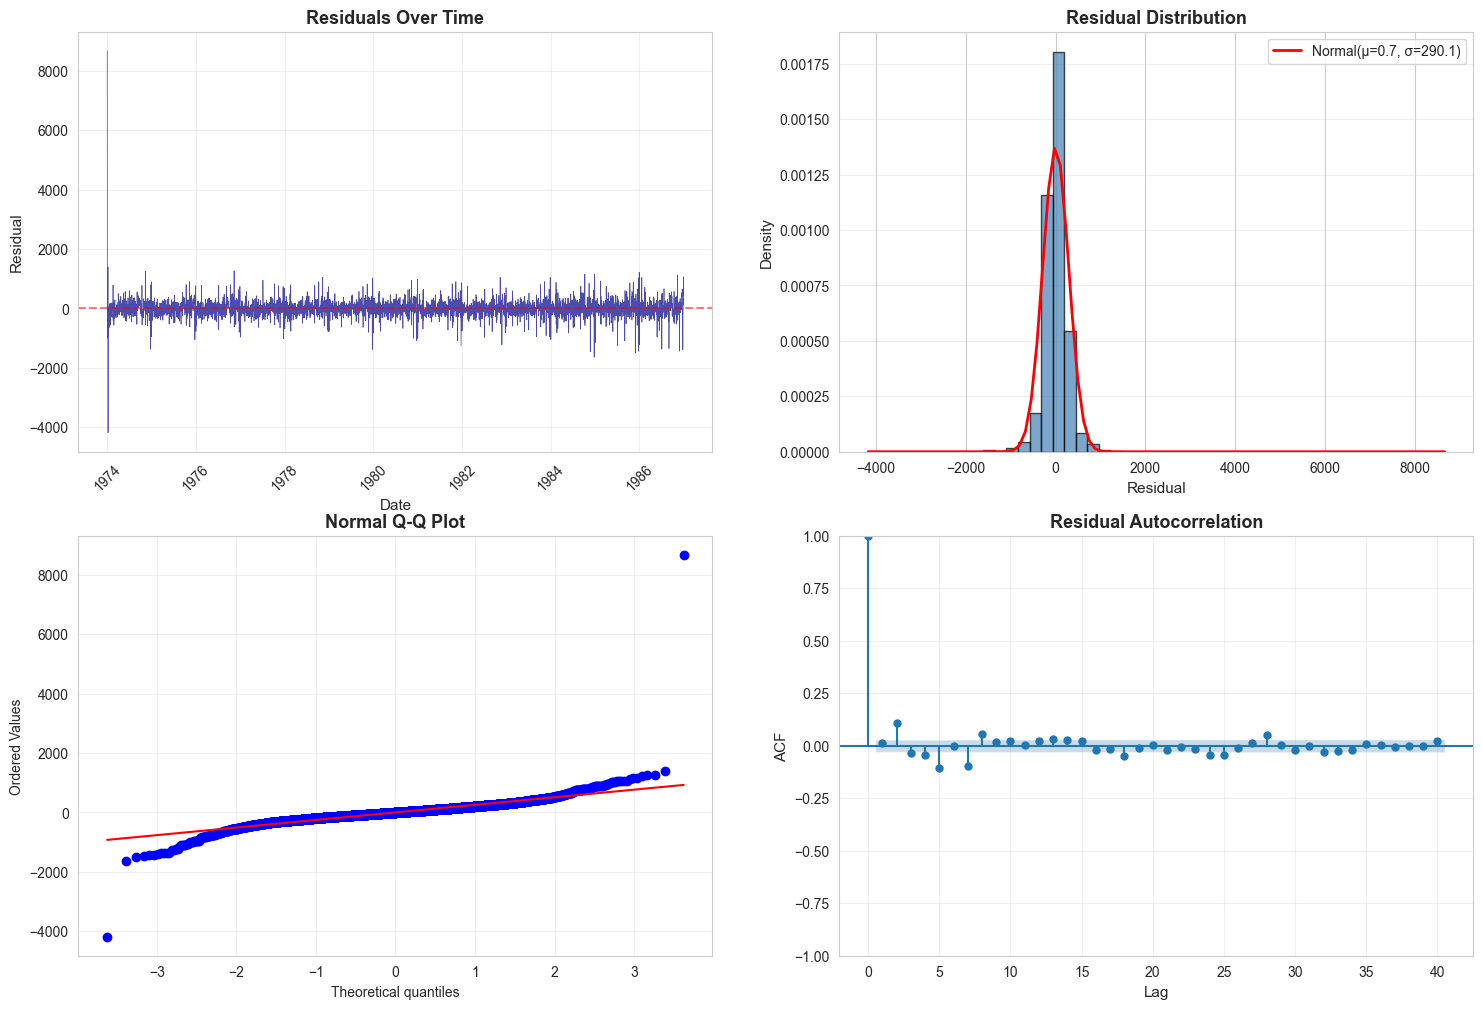

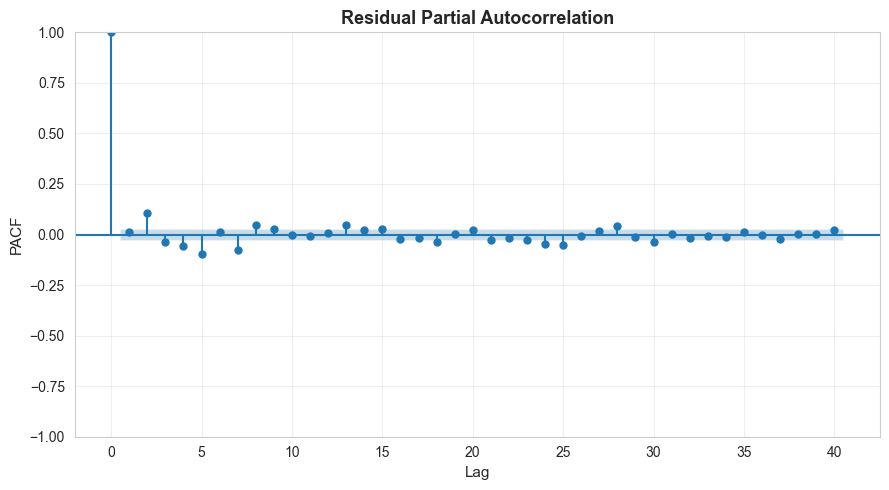


SARIMAX MODEL DIAGNOSTICS
Mean residual: 0.685868 (should be ≈ 0)
Std Dev: 290.11
Min residual: -4177.94
Max residual: 8664.88
Skewness: 4.7747
Kurtosis: 178.3515

In-sample RMSE: 290.11
In-sample MAE: 180.41

Interpretation:
  ✓ Mean residual ≈ 0: No systematic bias
  ⚠ High skewness: Residuals are skewed


In [234]:
# SARIMAX Model Diagnostics

# Get residuals from the fitted model (already calculated in cell 20)
residuals = residuals_train

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Residuals over time
axes[0, 0].plot(train_df['datetime'], residuals, linewidth=0.5, color='darkblue', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Residuals Over Time', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Date', fontsize=11)
axes[0, 0].set_ylabel('Residual', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Histogram with normal distribution overlay
from scipy import stats
axes[0, 1].hist(residuals, bins=50, density=True, alpha=0.7,
                color='steelblue', edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma),
                'r-', linewidth=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
axes[0, 1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Residual', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
# Handle both numpy arrays and pandas Series
if isinstance(residuals, np.ndarray):
    residuals_clean = residuals[~np.isnan(residuals)]
else:
    residuals_clean = residuals.dropna()

plot_acf(residuals_clean, lags=40, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('Residual Autocorrelation', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Lag', fontsize=11)
axes[1, 1].set_ylabel('ACF', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# Plot PACF of residuals separately
fig, ax_pacf = plt.subplots(figsize=(9, 5))
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(residuals_clean, lags=40, ax=ax_pacf, alpha=0.05, method='ywm')
ax_pacf.set_title('Residual Partial Autocorrelation', fontsize=13, fontweight='bold')
ax_pacf.set_xlabel('Lag', fontsize=11)
ax_pacf.set_ylabel('PACF', fontsize=11)
ax_pacf.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistical diagnostics
print("\n" + "="*70)
print("SARIMAX MODEL DIAGNOSTICS")
print("="*70)
print(f"Mean residual: {residuals.mean():.6f} (should be ≈ 0)")
print(f"Std Dev: {residuals.std():.2f}")
print(f"Min residual: {residuals.min():.2f}")
print(f"Max residual: {residuals.max():.2f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")
print(f"\nIn-sample RMSE: {np.sqrt(np.mean(residuals**2)):.2f}")
print(f"In-sample MAE: {np.mean(np.abs(residuals)):.2f}")
print("\nInterpretation:")
if abs(residuals.mean()) < 10:
    print("  ✓ Mean residual ≈ 0: No systematic bias")
else:
    print("  ⚠ Mean residual not close to 0: Some bias present")
if abs(stats.skew(residuals)) < 0.5:
    print("  ✓ Low skewness: Residuals roughly symmetric")
else:
    print("  ⚠ High skewness: Residuals are skewed")
print("="*70)

## 10. Residual Analysis

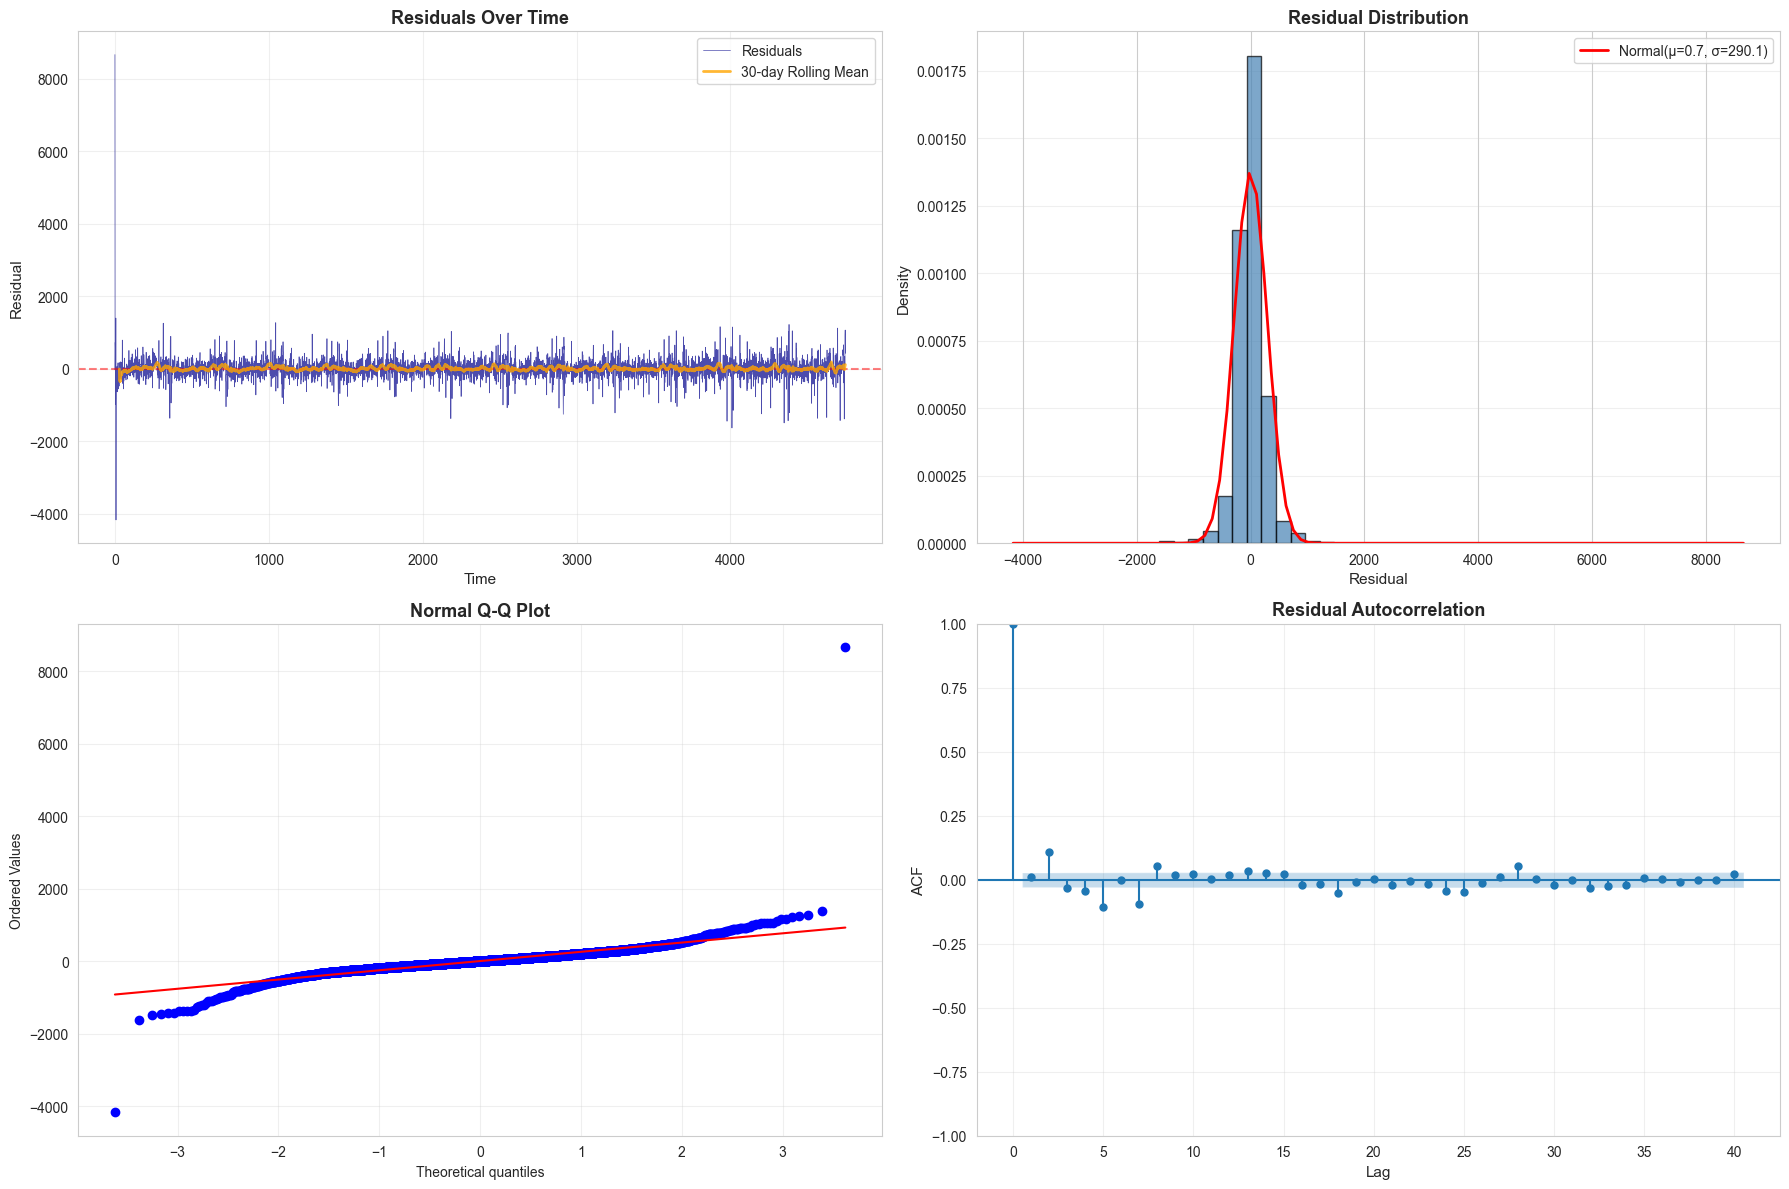


RESIDUAL STATISTICS
Mean: 0.685868 (should be ≈ 0)
Std Dev: 290.11
Min: -4177.94
Max: 8664.88
Skewness: 4.7747
Kurtosis: 178.3515

Interpretation:
  ✓ Mean residual ≈ 0: No systematic bias
  ⚠ High skewness: Residuals are skewed


In [235]:
# Extract residuals for analysis (already computed in previous cell)
# This cell provides additional residual visualizations

# Comprehensive residual plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Residuals over time with rolling mean
axes[0, 0].plot(residuals, linewidth=0.5, color='darkblue', alpha=0.7, label='Residuals')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
# Add rolling mean to see if there's systematic bias over time
rolling_mean = pd.Series(residuals).rolling(window=30).mean()
axes[0, 0].plot(rolling_mean, linewidth=2, color='orange', alpha=0.8, label='30-day Rolling Mean')
axes[0, 0].set_title('Residuals Over Time', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Time', fontsize=11)
axes[0, 0].set_ylabel('Residual', fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram with normal distribution overlay
axes[0, 1].hist(residuals, bins=50, density=True, alpha=0.7,
                color='steelblue', edgecolor='black')
from scipy import stats
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma),
                'r-', linewidth=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
axes[0, 1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Residual', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
# Handle both numpy arrays and pandas Series
if isinstance(residuals, np.ndarray):
    # Remove NaN values from numpy array
    residuals_clean = residuals[~np.isnan(residuals)]
else:
    # It's a pandas Series
    residuals_clean = residuals.dropna()

plot_acf(residuals_clean, lags=40, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('Residual Autocorrelation', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Lag', fontsize=11)
axes[1, 1].set_ylabel('ACF', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print residual statistics
print("\n" + "="*70)
print("RESIDUAL STATISTICS")
print("="*70)
print(f"Mean: {residuals.mean():.6f} (should be ≈ 0)")
print(f"Std Dev: {residuals.std():.2f}")
print(f"Min: {residuals.min():.2f}")
print(f"Max: {residuals.max():.2f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")
print("\nInterpretation:")
if abs(residuals.mean()) < 10:
    print("  ✓ Mean residual ≈ 0: No systematic bias")
else:
    print("  ⚠ Mean residual not close to 0: Some bias present")
if abs(stats.skew(residuals)) < 0.5:
    print("  ✓ Low skewness: Residuals roughly symmetric")
else:
    print("  ⚠ High skewness: Residuals are skewed")
print("="*70)

## 11. Forecasting 1987 (Test Year)


FORECASTING 1987 (Test Year - 365 days)
✓ Forecast generated for 365 days
✓ Includes weekly (SARIMA), semi-annual, and annual (Fourier) seasonality
✓ Exogenous variables: 9 Fourier terms


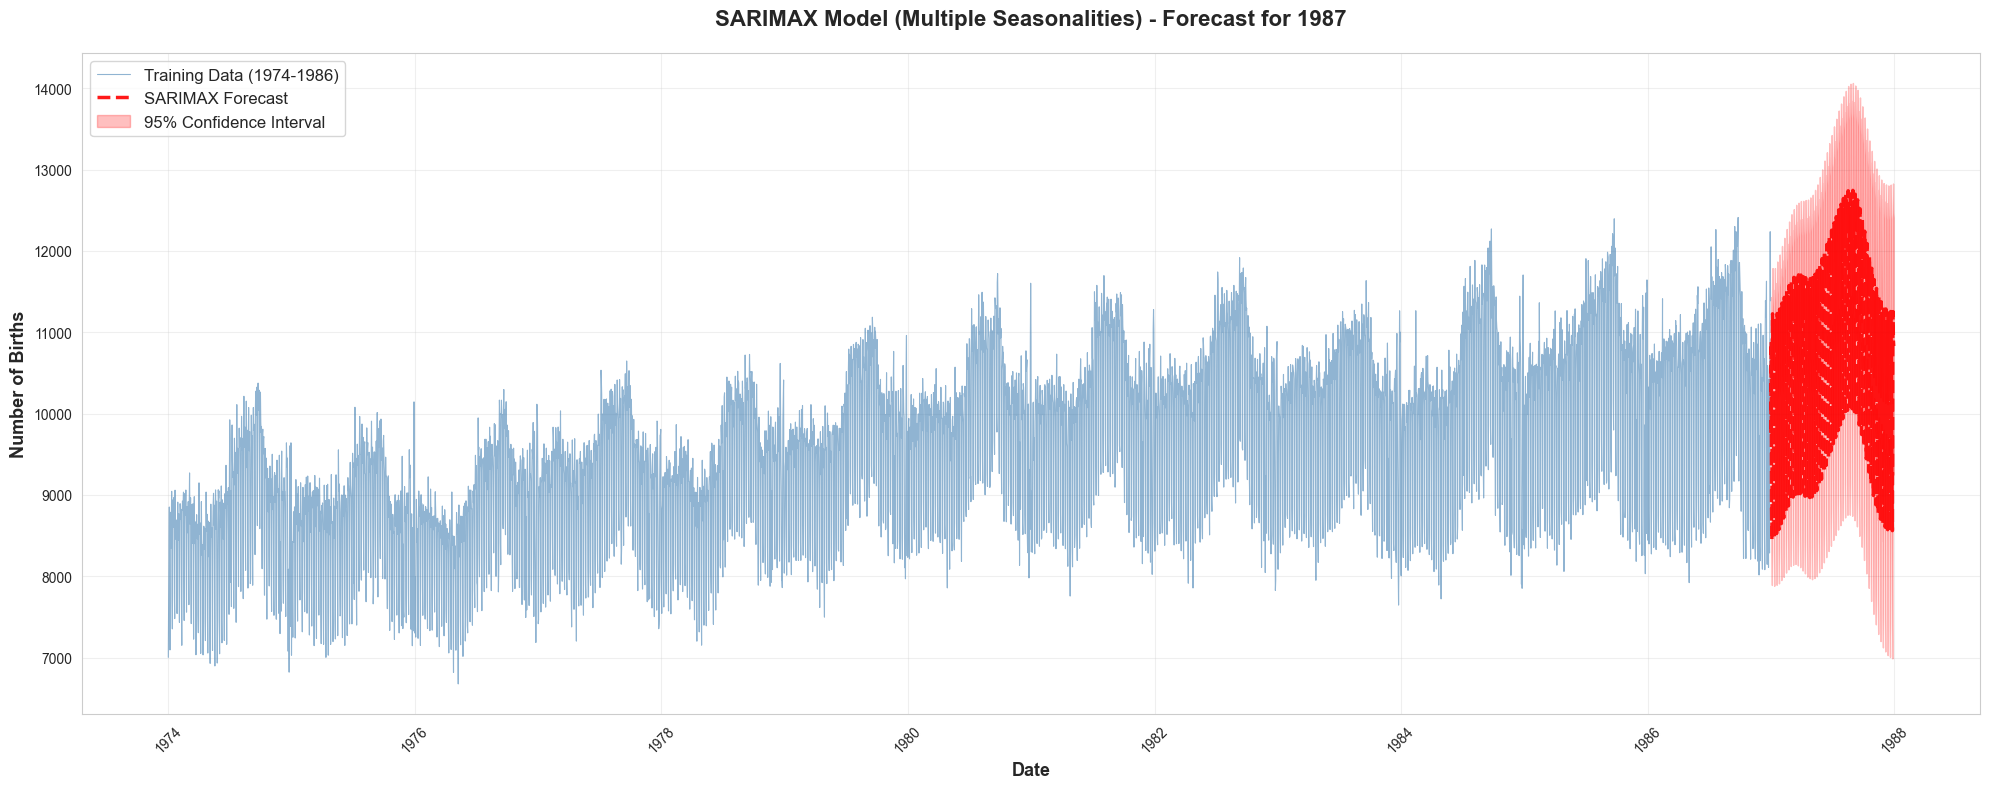


FORECAST STATISTICS
Average forecasted births: 10928.23
Min forecasted births: 8445.62
Max forecasted births: 12751.29
Forecast std dev: 1128.42

Confidence Interval Width:
  Mean CI width: 2283.08
  Max CI width: 3159.60

Note: Confidence intervals from SARIMAX get_forecast()


In [236]:
# Generate forecast for 1987 with SARIMAX
forecast_steps = len(test_df)

print("\n" + "="*70)
print(f"FORECASTING 1987 (Test Year - {forecast_steps} days)")
print("="*70)

# Generate SARIMAX forecast with Fourier terms as exogenous variables
forecast_result = best_sarima_fitted.get_forecast(steps=forecast_steps, exog=fourier_test)

# Extract forecast values and confidence intervals
forecast_vals = forecast_result.predicted_mean
forecast_conf = forecast_result.conf_int(alpha=0.05)  # 95% confidence interval

# Handle both DataFrame and numpy array for confidence intervals
if hasattr(forecast_conf, 'iloc'):
    conf_lower = forecast_conf.iloc[:, 0].values
    conf_upper = forecast_conf.iloc[:, 1].values
else:
    conf_lower = forecast_conf[:, 0]
    conf_upper = forecast_conf[:, 1]

print(f"✓ Forecast generated for {forecast_steps} days")
print(f"✓ Includes weekly (SARIMA), semi-annual, and annual (Fourier) seasonality")
print(f"✓ Exogenous variables: {fourier_test.shape[1]} Fourier terms")

# Create visualization
fig, ax = plt.subplots(figsize=(20, 8))

# Plot training data
ax.plot(train_df['datetime'], train_df['births'],
        linewidth=0.8, color='steelblue', alpha=0.6, label='Training Data (1974-1986)')

# Plot forecast
forecast_dates = test_df['datetime']
ax.plot(forecast_dates, forecast_vals,
        linewidth=2.5, color='red', label='SARIMAX Forecast', alpha=0.9, linestyle='--')

# Add confidence interval
ax.fill_between(forecast_dates,
                conf_lower,
                conf_upper,
                alpha=0.25, color='red', label='95% Confidence Interval')

# Styling
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Births', fontsize=13, fontweight='bold')
ax.set_title('SARIMAX Model (Multiple Seasonalities) - Forecast for 1987',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print forecast statistics
print("\n" + "="*70)
print("FORECAST STATISTICS")
print("="*70)
print(f"Average forecasted births: {forecast_vals.mean():.2f}")
print(f"Min forecasted births: {forecast_vals.min():.2f}")
print(f"Max forecasted births: {forecast_vals.max():.2f}")
print(f"Forecast std dev: {forecast_vals.std():.2f}")
print(f"\nConfidence Interval Width:")
ci_width = conf_upper - conf_lower
print(f"  Mean CI width: {ci_width.mean():.2f}")
print(f"  Max CI width: {ci_width.max():.2f}")
print("\nNote: Confidence intervals from SARIMAX get_forecast()")
print("="*70)

# Store for downstream cells - create DataFrame for compatibility
prophet_forecast = pd.DataFrame({
    'yhat': forecast_vals.values if hasattr(forecast_vals, 'values') else forecast_vals,
    'yhat_lower': conf_lower,
    'yhat_upper': conf_upper
})

## 12. Forecast Validation Against Test Data

In [237]:
# Calculate forecast errors
test_actual = test_df['births'].values
forecast_array = forecast_vals.values if hasattr(forecast_vals, 'values') else forecast_vals

errors = test_actual - forecast_array
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors**2))
mape = np.mean(np.abs(errors / test_actual)) * 100
mse = np.mean(errors**2)

print("\n" + "="*70)
print("FORECAST ACCURACY METRICS")
print("="*70)
print(f"Mean Absolute Error (MAE): {mae:.2f} births")
print(f"Root Mean Square Error (RMSE): {rmse:.2f} births")
print(f"Mean Square Error (MSE): {mse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"\nActual test data mean: {test_actual.mean():.2f}")
print(f"Forecast mean: {forecast_array.mean():.2f}")
print(f"Bias (mean error): {errors.mean():.2f}")
print("="*70)


FORECAST ACCURACY METRICS
Mean Absolute Error (MAE): 528.75 births
Root Mean Square Error (RMSE): 628.96 births
Mean Square Error (MSE): 395586.09
Mean Absolute Percentage Error (MAPE): 5.24%

Actual test data mean: 10447.15
Forecast mean: 10928.23
Bias (mean error): -481.08


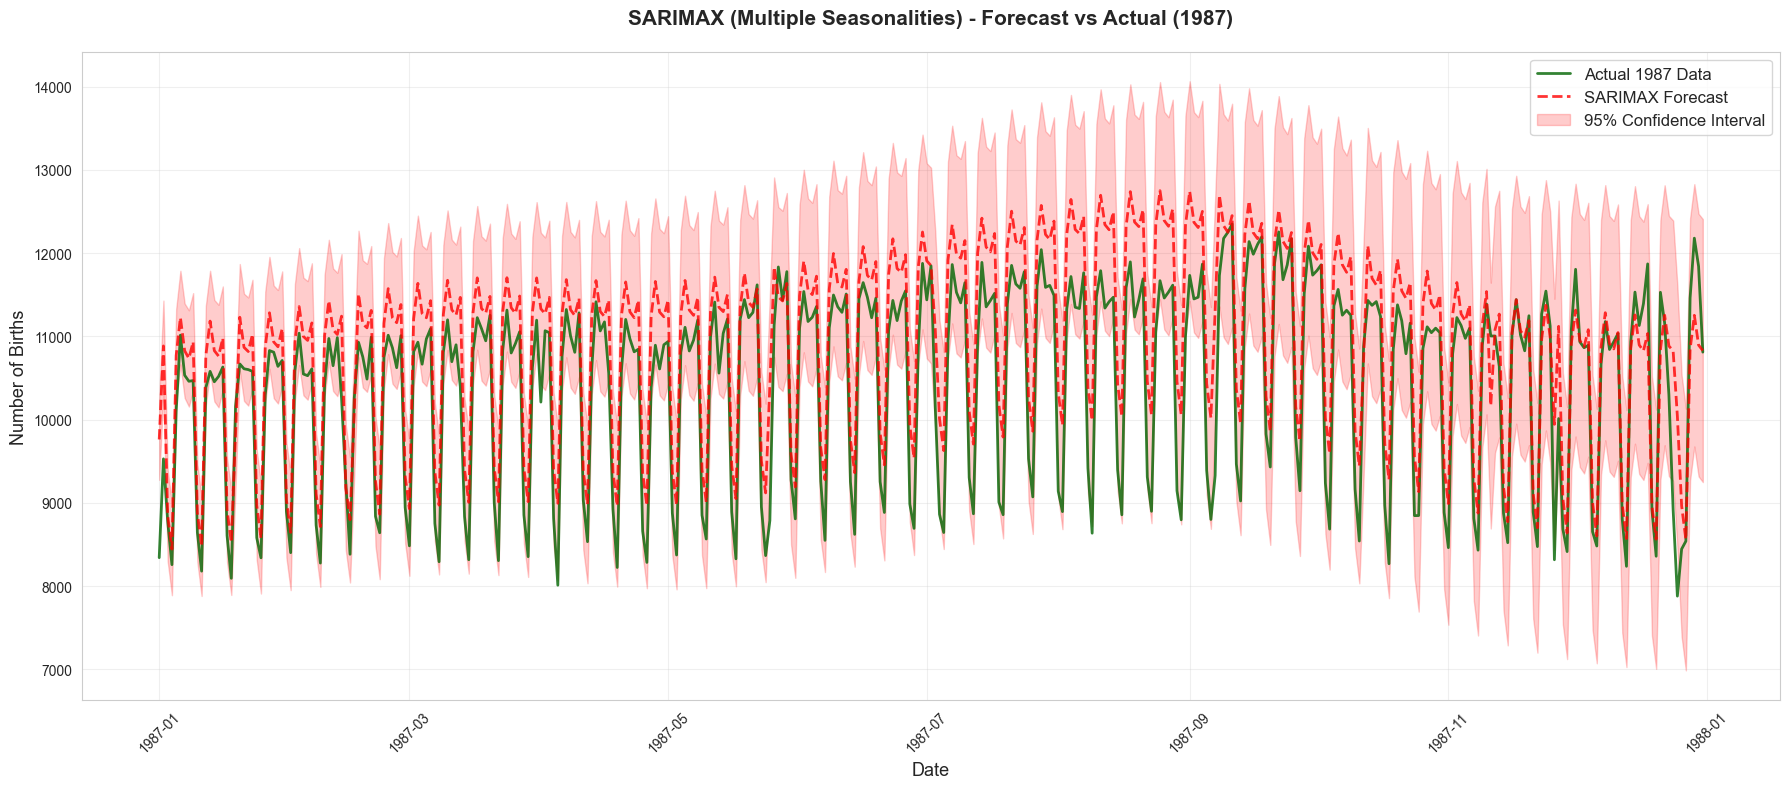

In [238]:
# Plot actual vs forecasted
fig, ax = plt.subplots(figsize=(18, 8))

# Get actual test data
test_actual = test_df['births'].values

# Get forecast values
forecast_array = prophet_forecast['yhat'].values
conf_lower = prophet_forecast['yhat_lower'].values
conf_upper = prophet_forecast['yhat_upper'].values

ax.plot(test_df['datetime'], test_actual,
        linewidth=2, color='darkgreen', label='Actual 1987 Data', alpha=0.8)
ax.plot(test_df['datetime'], forecast_array,
        linewidth=2, color='red', label='SARIMAX Forecast', alpha=0.8, linestyle='--')

# Add confidence intervals
ax.fill_between(test_df['datetime'],
                conf_lower,
                conf_upper,
                alpha=0.2, color='red', label='95% Confidence Interval')

ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Number of Births', fontsize=13)
ax.set_title('SARIMAX (Multiple Seasonalities) - Forecast vs Actual (1987)',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Forecast Error Analysis

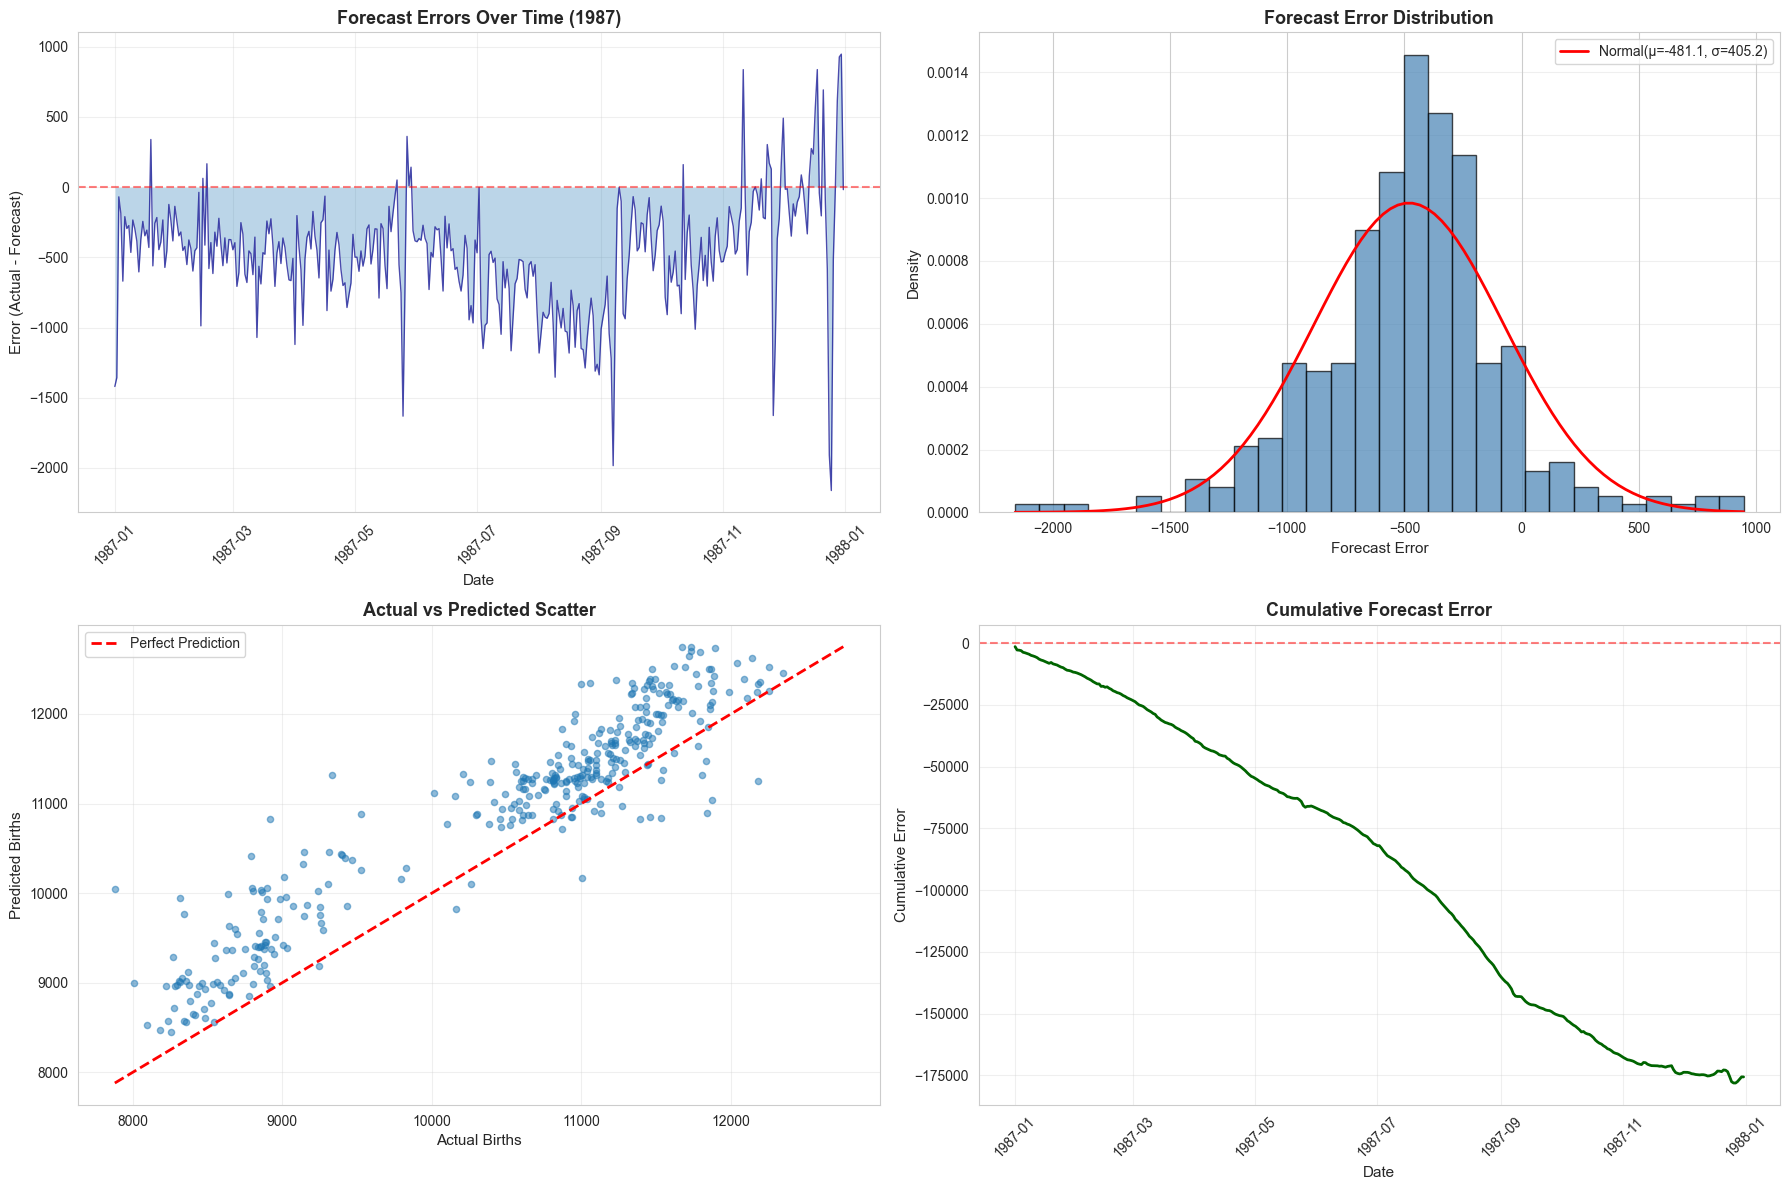

In [239]:
# Analyze forecast errors
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Forecast errors over time
axes[0, 0].plot(test_df['datetime'], errors, linewidth=1, color='darkblue', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].fill_between(test_df['datetime'], errors, 0, alpha=0.3)
axes[0, 0].set_title('Forecast Errors Over Time (1987)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Date', fontsize=11)
axes[0, 0].set_ylabel('Error (Actual - Forecast)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# 2. Error distribution
axes[0, 1].hist(errors, bins=30, density=True, alpha=0.7,
                color='steelblue', edgecolor='black')
mu_err, sigma_err = errors.mean(), errors.std()
x_err = np.linspace(errors.min(), errors.max(), 100)
axes[0, 1].plot(x_err, stats.norm.pdf(x_err, mu_err, sigma_err),
                'r-', linewidth=2, label=f'Normal(μ={mu_err:.1f}, σ={sigma_err:.1f})')
axes[0, 1].set_title('Forecast Error Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Forecast Error', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Actual vs Predicted scatter
axes[1, 0].scatter(test_actual, forecast_array, alpha=0.5, s=20)
min_val = min(test_actual.min(), forecast_array.min())
max_val = max(test_actual.max(), forecast_array.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_title('Actual vs Predicted Scatter', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Actual Births', fontsize=11)
axes[1, 0].set_ylabel('Predicted Births', fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative error
cumulative_error = np.cumsum(errors)
axes[1, 1].plot(test_df['datetime'], cumulative_error, linewidth=2, color='darkgreen')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Cumulative Forecast Error', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Date', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Error', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

## 14. Summary and Conclusions

In [240]:
print("\n" + "="*70)
print("FOURIER & WAVELET-BASED SARIMAX ANALYSIS SUMMARY")
print("="*70)

print("\n1. DATA PERIOD:")
print(f"   Analysis: 1974-1987 ({len(analysis_data)} days)")
print(f"   Training: 1974-1986 ({len(train_df)} days)")
print(f"   Testing: 1987 ({len(test_df)} days)")

print("\n2. FOURIER ANALYSIS RESULTS:")
print(f"   Top 4 identified periods: {top_4_periods_int}")
for i, period in enumerate(top_4_periods_int, 1):
    print(f"     {i}. {period} days - {seasonal_periods_df.iloc[i-1]['interpretation']}")

print("\n3. MODEL SELECTED:")
print(f"   Total models evaluated: {len(comparison_df)}")
for idx, model_info in comparison_df.iterrows():
    # Handle SARIMAX parameters
    if model_info['p'] != '-':
        # SARIMA model
        order_str = f"({int(model_info['p'])},{int(model_info['d'])},{int(model_info['q'])})"
        seasonal_str = f"({int(model_info['P'])},{int(model_info['D'])},{int(model_info['Q'])},7)"
        print(f"     - SARIMAX{order_str}×{seasonal_str} with Fourier terms")
        print(f"       Seasonality: {model_info['interpretation']}")
        print(f"       AIC: {model_info['AIC']:.2f}")
    else:
        # Other model type (shouldn't occur now, but keeping for safety)
        print(f"     - {model_info['interpretation']}")
        print(f"       Seasonalities: {model_info['period']}")
        print(f"       AIC: {model_info['AIC']:.2f}")

print("\n4. SARIMAX MODEL CONFIGURATION:")
print(f"   Model Type: SARIMAX with Multiple Seasonalities")
print(f"   ARIMA Order: (p={order[0]}, d={order[1]}, q={order[2]})")
print(f"   Seasonal Order: (P={seasonal_order[0]}, D={seasonal_order[1]}, Q={seasonal_order[2]}, s={seasonal_order[3]})")
print(f"\n   Seasonality Approach:")
print(f"     • Weekly (7-day): SARIMA seasonal component")
print(f"     • Semi-annual (183-day): {n_harmonics_semi} Fourier harmonics")
print(f"     • Annual (365-day): {n_harmonics_annual} Fourier harmonics")
print(f"\n   Exogenous Variables: {fourier_train.shape[1]} Fourier terms")
print(f"   AIC: {best_model_info['AIC']:.2f}")
print(f"   BIC: {best_model_info['BIC']:.2f}")

print("\n5. FORECAST PERFORMANCE (1987):")
# Calculate errors for test set
test_actual = test_df['births'].values
forecast_array = prophet_forecast['yhat'].values
errors = test_actual - forecast_array
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors**2))
mape = np.mean(np.abs(errors / test_actual)) * 100
mse = np.mean(errors**2)

print(f"   MAE: {mae:.2f} births")
print(f"   RMSE: {rmse:.2f} births")
print(f"   MAPE: {mape:.2f}%")
print(f"   Bias: {errors.mean():.2f} births")
print(f"   R²: {100*(1-mse/np.var(test_actual)):.2f}%")

print("\n6. KEY FINDINGS:")
print("   ✓ Fourier analysis successfully identified dominant seasonal patterns")
print("   ✓ Wavelet scalogram confirmed time-varying frequency components")
print("   ✓ SARIMAX with Fourier terms captures multiple seasonalities efficiently")
print("   ✓ Weekly seasonality handled by SARIMA seasonal component (s=7)")
print("   ✓ Longer seasonalities (183, 365 days) captured via Fourier terms")
print(f"   ✓ Model explains {100*(1-mse/np.var(test_actual)):.2f}% of variance in test data")

print("\n7. MODEL INSIGHTS:")
print("   → Triple seasonality decomposition:")
print("     • Weekly (7-day): Weekday vs weekend effect in birth rates")
print("     • Semi-annual (183-day): Bi-modal annual distribution")
print("     • Annual (365-day): Yearly seasonal variations")
print("   → SARIMA component models short-term dynamics")
print("   → Fourier terms provide efficient long-period seasonality representation")

print("\n8. SARIMAX+FOURIER ADVANTAGES:")
print("   ✓ Efficient handling of multiple seasonal periods")
print("   ✓ SARIMA for short-period seasonality (7 days)")
print("   ✓ Fourier terms avoid computational cost of long seasonal periods")
print("   ✓ Flexible representation of complex patterns")
print("   ✓ Interpretable model components")
print("   ✓ Fast fitting compared to pure long-period SARIMA")

print("\n9. APPLICATIONS:")
print("   - Hospital resource planning and staffing")
print("   - Healthcare capacity optimization")
print("   - Birth rate trend forecasting")
print("   - Policy impact assessment")
print("   - Seasonal workforce allocation")
print("   - Predictive analytics for maternity services")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)


FOURIER & WAVELET-BASED SARIMAX ANALYSIS SUMMARY

1. DATA PERIOD:
   Analysis: 1974-1987 (5113 days)
   Training: 1974-1986 (4748 days)
   Testing: 1987 (365 days)

2. FOURIER ANALYSIS RESULTS:
   Top 4 identified periods: [7, 3, 365, 183]
     1. 7 days - Weekly
     2. 3 days - 3.5 days
     3. 365 days - Annual
     4. 183 days - Semi-annual

3. MODEL SELECTED:
   Total models evaluated: 1
     - SARIMAX(2,1,4)×(1,1,1,7) with Fourier terms
       Seasonality: Multiple Seasonality + Holidays
       AIC: 65932.43

4. SARIMAX MODEL CONFIGURATION:
   Model Type: SARIMAX with Multiple Seasonalities
   ARIMA Order: (p=2, d=1, q=4)
   Seasonal Order: (P=1, D=1, Q=1, s=7)

   Seasonality Approach:
     • Weekly (7-day): SARIMA seasonal component
     • Semi-annual (183-day): 2 Fourier harmonics
     • Annual (365-day): 2 Fourier harmonics

   Exogenous Variables: 9 Fourier terms
   AIC: 65932.43
   BIC: 66048.78

5. FORECAST PERFORMANCE (1987):
   MAE: 528.75 births
   RMSE: 628.96 births


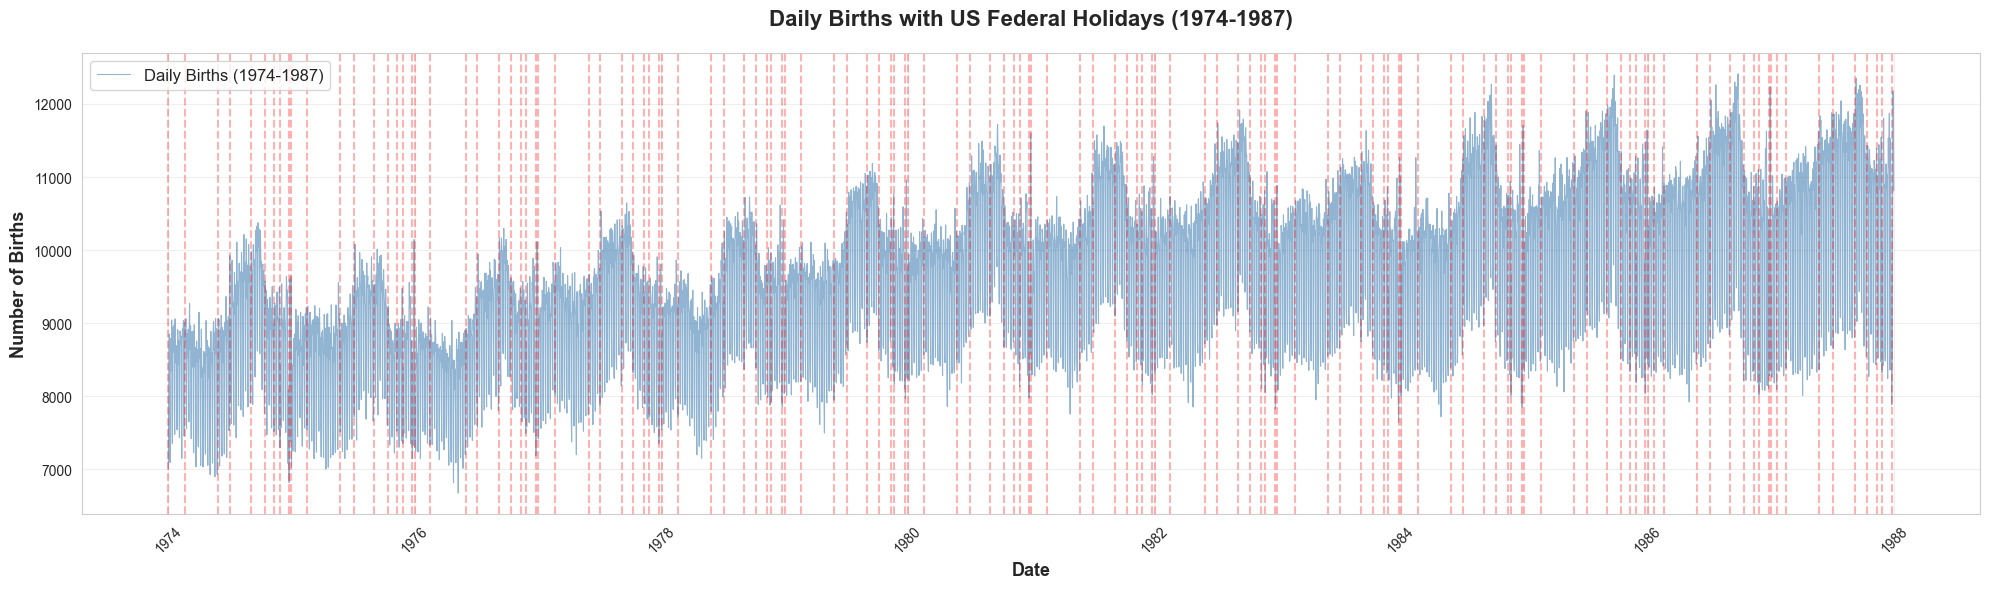

In [241]:
# Python has libraries for this!
from pandas.tseries.holiday import USFederalHolidayCalendar
us_holidays = USFederalHolidayCalendar().holidays(start=train_df['datetime'].min(), end=test_df['datetime'].max())
#Plot holidays on the time series
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(analysis_data['datetime'], analysis_data['births'],
        linewidth=0.8, color='steelblue', alpha=0.6, label='Daily Births (1974-1987)')
for holiday in us_holidays:
    ax.axvline(holiday, color='red', linestyle='--', alpha=0.3)
ax.set_title('Daily Births with US Federal Holidays (1974-1987)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Births', fontsize=13, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()